# Part 1: Initial Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
BASE_DIR       = "/content/drive/MyDrive/CS229"
SUNO_DRIVE_DIR = BASE_DIR + "/sunoCaps"
FMA_DRIVE_DIR  = BASE_DIR + "/fma_subset_1000"
FMA_SUBSET_N   = 1000
SEED           = 42

import os
os.makedirs(SUNO_DRIVE_DIR, exist_ok=True)
os.makedirs(FMA_DRIVE_DIR,  exist_ok=True)
print("Drive folders ready.")

Drive folders ready.


### 1a. Download & Extract SunoCaps (AI-generated music)

# Part 2: Load Datasets


In [3]:
from google.colab import drive
drive.mount("/content/drive")

import os, glob, random, numpy as np, pandas as pd, librosa
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR       = "/content/drive/MyDrive/CS229"
SUNO_DRIVE_DIR = BASE_DIR + "/sunoCaps"
FMA_DRIVE_DIR  = BASE_DIR + "/fma_subset_1000"
SEED           = 42

suno_files = glob.glob(SUNO_DRIVE_DIR + "/*.mp3")
fma_files  = glob.glob(FMA_DRIVE_DIR  + "/*.mp3")
print(f"AI clips: {len(suno_files)}  |  Human clips: {len(fma_files)}")

data = (
    [{"path": f, "label": 1} for f in suno_files] +
    [{"path": f, "label": 0} for f in fma_files]
)
df = pd.DataFrame(data).sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f"Total dataset: {len(df)} clips")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
AI clips: 256  |  Human clips: 999
Total dataset: 1255 clips


,path,label
0,/content/drive/MyDrive/CS229/fma_subset_1000/0...,0
1,/content/drive/MyDrive/CS229/sunoCaps/1JwoLPCI...,1
2,/content/drive/MyDrive/CS229/sunoCaps/20Vh6z6I...,1
3,/content/drive/MyDrive/CS229/sunoCaps/1W2FOzSX...,1
4,/content/drive/MyDrive/CS229/fma_subset_1000/0...,0


# Part 3: Feature Extraction
Extracts a 29-dimensional feature vector per clip:
- 13 MFCCs (timbral texture)
- Spectral centroid, rolloff, flatness (brightness / noise)  
- 12 Chroma features (harmonic content)  
- 1 Phase deviation (generative artifact signal)


In [4]:
def extract_features(file_path):
    """Extract a 29-dim feature vector from an audio file."""
    try:
        y, sr = librosa.load(file_path, sr=22050, duration=30.0)

        mfccs              = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        spectral_centroid  = librosa.feature.spectral_centroid(y=y, sr=sr)
        spectral_rolloff   = librosa.feature.spectral_rolloff(y=y, sr=sr)
        spectral_flatness  = librosa.feature.spectral_flatness(y=y)
        chroma             = librosa.feature.chroma_stft(y=y, sr=sr)

        D          = librosa.stft(y)
        phase      = np.angle(D)
        phase_diff = np.diff(phase, axis=1)
        phase_dev  = np.mean(np.abs(phase_diff))

        return np.hstack([
            np.mean(mfccs, axis=1),           # 13
            np.mean(spectral_centroid),        #  1
            np.mean(spectral_rolloff),         #  1
            np.mean(spectral_flatness),        #  1
            np.mean(chroma, axis=1),           # 12
            phase_dev,                         #  1
        ])                                     # = 29 total
    except Exception as e:
        print(f"Error: {file_path}  →  {e}")
        return None

In [5]:
FEATURE_PATH = BASE_DIR + "/X_features.npy"
LABEL_PATH   = BASE_DIR + "/y_labels.npy"
PATHS_PATH   = BASE_DIR + "/file_paths.npy"

if os.path.exists(FEATURE_PATH):
    print("Found saved features — loading from Drive.")
    X           = np.load(FEATURE_PATH)
    y           = np.load(LABEL_PATH)
    valid_paths = np.load(PATHS_PATH, allow_pickle=True)
else:
    print("Extracting features... (this takes a few minutes)")
    features_list = [extract_features(p) for p in df['path']]
    valid_idx   = [i for i, f in enumerate(features_list) if f is not None]
    X           = np.array([features_list[i] for i in valid_idx])
    y           = df['label'].iloc[valid_idx].values
    valid_paths = df['path'].iloc[valid_idx].values

    np.save(FEATURE_PATH, X)
    np.save(LABEL_PATH,   y)
    np.save(PATHS_PATH,   valid_paths)
    print("Saved to Drive.")

FEATURE_NAMES = (
    [f'MFCC_{i+1}' for i in range(13)] +
    ['SpecCentroid', 'SpecRolloff', 'SpecFlatness'] +
    [f'Chroma_{i+1}' for i in range(12)] +
    ['PhaseDev']
)

print(f"Feature matrix: {X.shape}  |  Labels: {y.shape}")

Found saved features — loading from Drive.
Feature matrix: (1255, 29)  |  Labels: (1255,)


# Part 4: Sklearn Baseline Models
Logistic Regression (L1 & L2), RBF-SVM — for comparison against the DNN.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.calibration import CalibrationDisplay

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

Train: 1004  |  Test: 251


In [7]:
lr_l2 = Pipeline([('scaler', StandardScaler()),
                  ('lr', LogisticRegression(penalty='l2', C=1.0, max_iter=1000))])
lr_l2.fit(X_train, y_train)
print("=== Logistic Regression (L2) ===")
print(classification_report(y_test, lr_l2.predict(X_test), target_names=['Human','AI']))
print(f"ROC AUC: {roc_auc_score(y_test, lr_l2.predict_proba(X_test)[:,1]):.4f}")

=== Logistic Regression (L2) ===
              precision    recall  f1-score   support

       Human       0.92      0.94      0.93       200
          AI       0.74      0.69      0.71        51

    accuracy                           0.89       251
   macro avg       0.83      0.81      0.82       251
weighted avg       0.89      0.89      0.89       251

ROC AUC: 0.9287


In [8]:
lr_l1 = Pipeline([('scaler', StandardScaler()),
                  ('lr', LogisticRegression(penalty='l1', C=1.0, solver='liblinear', max_iter=1000))])
lr_l1.fit(X_train, y_train)
print("=== Logistic Regression (L1) ===")
print(classification_report(y_test, lr_l1.predict(X_test), target_names=['Human','AI']))

coefs = lr_l1.named_steps['lr'].coef_[0]
zeroed = [FEATURE_NAMES[i] for i, c in enumerate(coefs) if c == 0]
print(f"Features zeroed out by L1 ({len(zeroed)}): {zeroed}")

=== Logistic Regression (L1) ===
              precision    recall  f1-score   support

       Human       0.92      0.94      0.93       200
          AI       0.73      0.69      0.71        51

    accuracy                           0.88       251
   macro avg       0.83      0.81      0.82       251
weighted avg       0.88      0.88      0.88       251

Features zeroed out by L1 (2): ['Chroma_10', 'Chroma_12']


In [9]:
svm = Pipeline([('scaler', StandardScaler()),
                ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True))])
svm.fit(X_train, y_train)
print("=== RBF-SVM ===")
print(classification_report(y_test, svm.predict(X_test), target_names=['Human','AI']))
print(f"ROC AUC: {roc_auc_score(y_test, svm.predict_proba(X_test)[:,1]):.4f}")

=== RBF-SVM ===
              precision    recall  f1-score   support

       Human       0.93      0.98      0.96       200
          AI       0.93      0.73      0.81        51

    accuracy                           0.93       251
   macro avg       0.93      0.86      0.89       251
weighted avg       0.93      0.93      0.93       251

ROC AUC: 0.9640


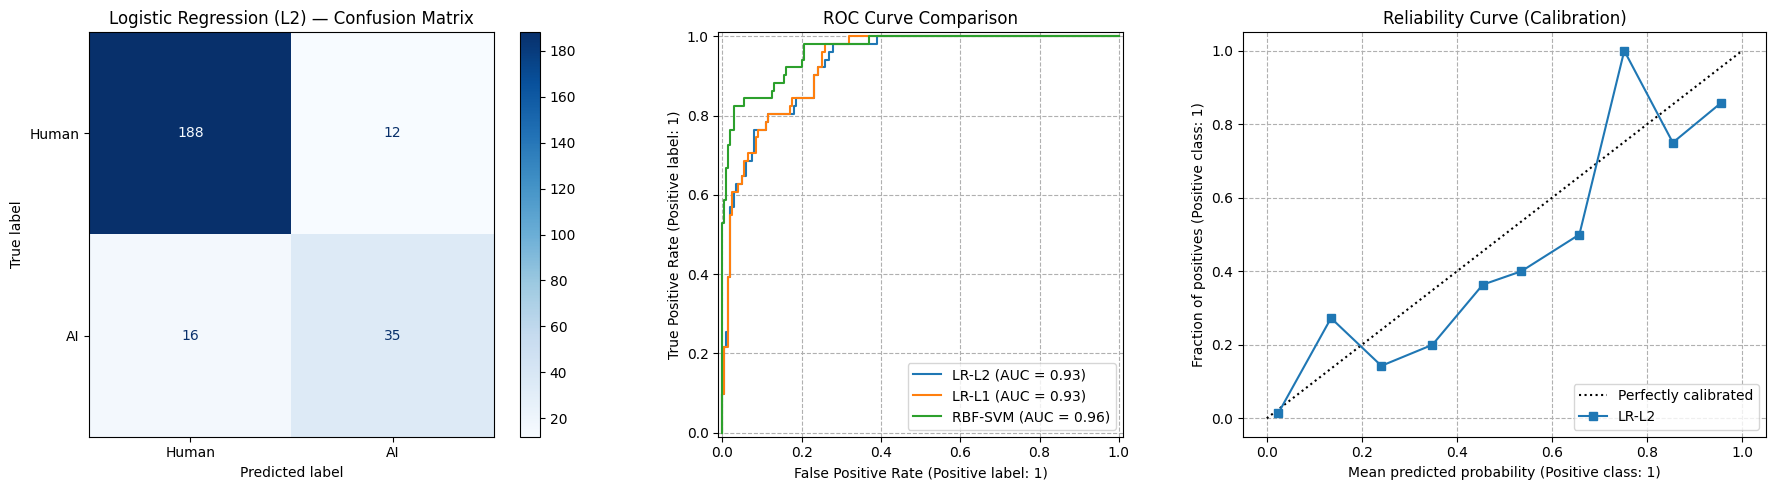

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_estimator(
    lr_l2, X_test, y_test, display_labels=['Human','AI'], cmap='Blues', ax=axes[0])
axes[0].set_title("Logistic Regression (L2) — Confusion Matrix")

for model, name in [(lr_l2, 'LR-L2'), (lr_l1, 'LR-L1'), (svm, 'RBF-SVM')]:
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[1], name=name)
axes[1].set_title("ROC Curve Comparison")
axes[1].grid(linestyle='--')

CalibrationDisplay.from_estimator(
    lr_l2, X_test, y_test, n_bins=10, name='LR-L2', ax=axes[2])
axes[2].set_title("Reliability Curve (Calibration)")
axes[2].grid(linestyle='--')

plt.tight_layout()
plt.show()

/tmp/ipykernel_31224/3243975437.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[FEATURE_NAMES[i] for i in order], y=coefs_l2[order], palette='vlag')


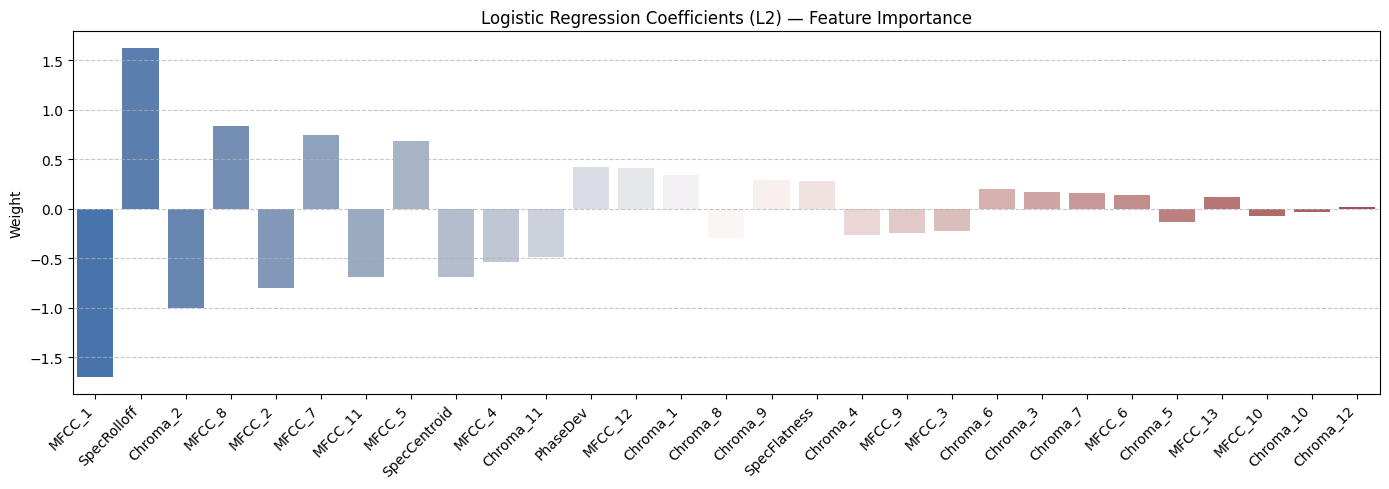

In [11]:
coefs_l2 = lr_l2.named_steps['lr'].coef_[0]
order    = np.argsort(np.abs(coefs_l2))[::-1]

plt.figure(figsize=(14, 5))
sns.barplot(x=[FEATURE_NAMES[i] for i in order], y=coefs_l2[order], palette='vlag')
plt.title("Logistic Regression Coefficients (L2) — Feature Importance")
plt.ylabel("Weight")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

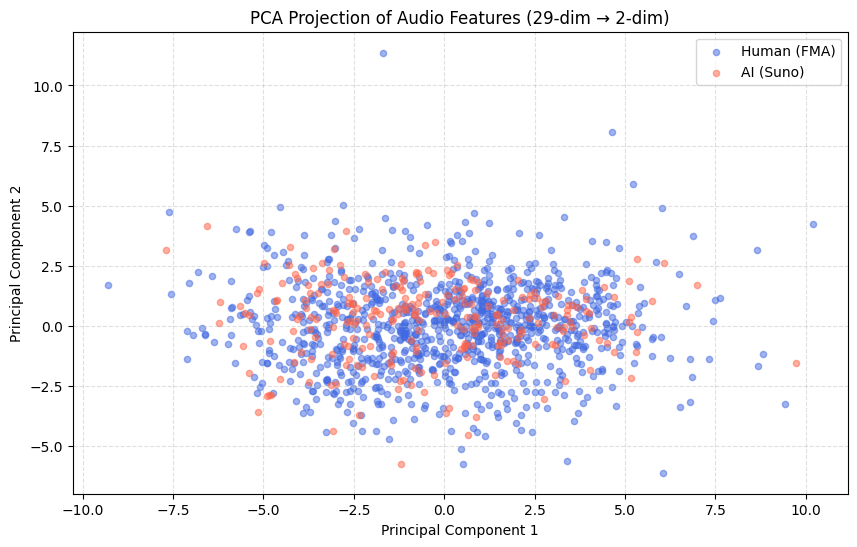

In [12]:
from sklearn.decomposition import PCA

pca_pipe = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=2))])
X_pca    = pca_pipe.fit_transform(X)

plt.figure(figsize=(10, 6))
for label, color, name in zip([0, 1], ['royalblue', 'tomato'], ['Human (FMA)', 'AI (Suno)']):
    idx = np.where(y == label)
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], c=color, label=name, alpha=0.5, s=20)
plt.title("PCA Projection of Audio Features (29-dim → 2-dim)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(linestyle='--', alpha=0.4)
plt.show()

# Part 5: PyTorch Deep Neural Network
Two models:
- MusicMLP — uses the saved feature vectors; fast, directly comparable to sklearn baselines
- MusicCNN — reads raw audio as mel-spectrograms; learns its own features end-to-end

In [13]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torch.optim.lr_scheduler import CosineAnnealingLR

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
torch.manual_seed(SEED)

Device: cuda


### 5a. Model Definitions

In [14]:
class MusicMLP(nn.Module):
    #MLP over tabular feature vectors. BatchNorm replaces StandardScaler.
    def __init__(self, input_dim=29, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(input_dim),
            nn.Linear(input_dim, 128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, 64),        nn.GELU(), nn.Dropout(dropout - 0.1),
            nn.Linear(64, 32),         nn.GELU(),
            nn.Linear(32, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)   # raw logits


#Music CNN
class ResidualBlock(nn.Module):
    def __init__(self, channels, dropout = 0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels), nn.GELU(),
            nn.Dropout2d(dropout),
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )
        self.act = nn.GELU()
    def forward(self, x):
        return self.act(x + self.block(x))

class MusicCNN(nn.Module):
    """CNN over mel-spectrograms. No hand-crafted features needed."""
    def __init__(self, n_mels=64, dropout=0.4):
        super().__init__()
        self.stem    = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=(2,1), padding=1, bias=False),
            nn.BatchNorm2d(32), nn.GELU(),
        )
        self.res1    = ResidualBlock(32)
        self.pool1   = nn.MaxPool2d(2)
        self.expand2 = nn.Conv2d(32, 64, 1, bias=False)
        self.res2    = ResidualBlock(64)
        self.pool2   = nn.MaxPool2d(2)
        self.expand3 = nn.Conv2d(64, 128, 1, bias=False)
        self.res3    = ResidualBlock(128)
        self.gap     = nn.AdaptiveAvgPool2d(1)
        self.head    = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(64, 1),
        )
    def forward(self, x):
        x = self.stem(x)
        x = self.pool1(self.res1(x))
        x = self.pool2(self.res2(self.expand2(x)))
        x = self.gap(self.res3(self.expand3(x)))
        return self.head(x).squeeze(-1)

mlp_params = sum(p.numel() for p in MusicMLP().parameters())
cnn_params = sum(p.numel() for p in MusicCNN().parameters())
print(f"MusicMLP parameters: {mlp_params:,}")
print(f"MusicCNN parameters: {cnn_params:,}")

MusicMLP parameters: 14,267
MusicCNN parameters: 406,881


### 5b. Datasets

In [15]:
class FeatureDataset(Dataset):
    """Wraps saved numpy arrays for the MLP."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


class AudioDataset(Dataset):
    """Loads raw audio and returns mel-spectrograms for the CNN."""
    def __init__(self, df, sr=22050, duration=30.0, n_mels=64, n_fft=1024, hop_length=512, training=False):
        self.paths      = df['path'].values
        self.labels     = df['label'].values
        self.sr         = sr
        self.n_samples  = int(sr * duration)
        self.n_mels     = n_mels
        self.n_fft      = n_fft
        self.hop_length = hop_length
        self.training   = training

    def set_training(self, mode: bool):
        self.training = mode

    def __len__(self): return len(self.labels)

    def _spectrogram(self, path):
        y, _ = librosa.load(path, sr=self.sr, duration=None)

        # Normalize loudness so the CNN can't exploit mastering differences
        target_rms  = 0.1
        current_rms = np.sqrt(np.mean(y**2)) + 1e-8
        y           = y * (target_rms / current_rms)

        if len(y) < self.n_samples:
            y = np.pad(y, (0, self.n_samples - len(y)))
        else:
            y = y[:self.n_samples]

        mel    = librosa.feature.melspectrogram(y=y, sr=self.sr,
                     n_mels=self.n_mels, n_fft=self.n_fft, hop_length=self.hop_length)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
        return torch.tensor(mel_db, dtype=torch.float32).unsqueeze(0)  # (1, n_mels, T)

    def _augment(self, mel_db):
        # Frequency masking: zero out up to 10 mel bins
        f_start = random.randint(0, mel_db.shape[1] - 10)
        mel_db[:, f_start:f_start+10, :] = 0
        # Time masking: zero out up to 20 time steps
        t_start = random.randint(0, mel_db.shape[2] - 20)
        mel_db[:, :, t_start:t_start+20] = 0
        return mel_db

    def __getitem__(self, i):
        try:
            spec = self._spectrogram(self.paths[i])
            if self.training:
                spec = self._augment(spec)
        except Exception as e:
            print(f"Load error {self.paths[i]}: {e}")
            T    = self.n_samples // self.hop_length + 1
            spec = torch.zeros(1, self.n_mels, T)
        return spec, torch.tensor(self.labels[i], dtype=torch.float32)

### 5c. Training Loop

In [16]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = correct = n = 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(yb)
        correct    += ((torch.sigmoid(logits) > 0.5).float() == yb).sum().item()
        n          += len(yb)
    return total_loss / n, correct / n


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = correct = n = 0
    all_probs, all_labels = [], []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        probs  = torch.sigmoid(logits)
        total_loss += criterion(logits, yb).item() * len(yb)
        correct    += ((probs > 0.5).float() == yb).sum().item()
        n          += len(yb)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())
    return total_loss / n, correct / n, np.array(all_probs), np.array(all_labels)


def train_model(model, train_loader, val_loader, epochs=50, lr=1e-3,
                weight_decay=1e-3, patience=8, save_path="best_model.pt"):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr / 20)

    best_val_loss = float('inf')
    patience_ctr  = 0
    history       = dict(train_loss=[], val_loss=[], train_acc=[], val_acc=[])

    print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7}")
    print("─" * 55)

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc            = train_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc, _, _      = eval_epoch(model, val_loader, criterion)
        scheduler.step()

        for k, v in zip(history, [tr_loss, vl_loss, tr_acc, vl_acc]):
            history[k].append(v)

        tag = ""
        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            patience_ctr  = 0
            torch.save(model.state_dict(), save_path)
            tag = "  ✓"
        else:
            patience_ctr += 1

        print(f"{epoch:>6} | {tr_loss:>10.4f} | {tr_acc:>8.2%} | {vl_loss:>8.4f} | {vl_acc:>6.2%}{tag}")

        if patience_ctr >= patience:
            print(f"\nEarly stop at epoch {epoch}.")
            break

    model.load_state_dict(torch.load(save_path, map_location=DEVICE))
    print(f"Best model restored from {save_path}")
    return history

### 5d. Evaluation & Plotting

In [17]:
def plot_history(history, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history['train_loss'], label='Train')
    axes[0].plot(history['val_loss'],   label='Val')
    axes[0].set_title(f"{title} — Loss"); axes[0].set_xlabel("Epoch")
    axes[0].legend(); axes[0].grid(linestyle='--', alpha=0.6)

    axes[1].plot(history['train_acc'], label='Train')
    axes[1].plot(history['val_acc'],   label='Val')
    axes[1].set_title(f"{title} — Accuracy"); axes[1].set_xlabel("Epoch")
    axes[1].legend(); axes[1].grid(linestyle='--', alpha=0.6)
    plt.tight_layout(); plt.show()


def evaluate_model(model, loader, model_name="DNN"):
    criterion = nn.BCEWithLogitsLoss()
    _, acc, probs, labels = eval_epoch(model, loader, criterion)
    preds = (probs > 0.5).astype(int)

    print(f"\n{'='*40}")
    print(f"  {model_name} — Test Results")
    print(f"{'='*40}")
    print(classification_report(labels, preds, target_names=['Human','AI']))
    print(f"ROC AUC: {roc_auc_score(labels, probs):.4f}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    ConfusionMatrixDisplay.from_predictions(
        labels, preds, display_labels=['Human','AI'], cmap='Blues', ax=axes[0])
    axes[0].set_title(f"{model_name} — Confusion Matrix")

    RocCurveDisplay.from_predictions(labels, probs, ax=axes[1], name=model_name)
    axes[1].set_title("ROC Curve"); axes[1].grid(linestyle='--')

    CalibrationDisplay.from_predictions(
        labels, probs, n_bins=10, name=model_name, ax=axes[2])
    axes[2].set_title("Reliability Curve"); axes[2].grid(linestyle='--')

    plt.tight_layout(); plt.show()
    return probs, labels

### 5e. Train MusicMLP (on saved features — fast)

In [18]:
full_ds  = FeatureDataset(X, y)
n_test   = int(0.15 * len(full_ds))
n_val    = int(0.15 * len(full_ds))
n_train  = len(full_ds) - n_val - n_test
g        = torch.Generator().manual_seed(SEED)
train_ds, val_ds, test_ds = random_split(full_ds, [n_train, n_val, n_test], generator=g)

mlp_train = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=2)
mlp_val   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=2)
mlp_test  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=2)

print(f"Train: {n_train}  |  Val: {n_val}  |  Test: {n_test}")

Train: 879  |  Val: 188  |  Test: 188


In [19]:
model_mlp = MusicMLP(input_dim=X.shape[1]).to(DEVICE)

mlp_history = train_model(
    model_mlp, mlp_train, mlp_val,
    epochs=60, lr=1e-3, patience=8,
    save_path=BASE_DIR + "/best_mlp.pt"
)

 Epoch | Train Loss | Train Acc | Val Loss | Val Acc
───────────────────────────────────────────────────────
     1 |     0.6821 |   53.47% |   0.6406 | 79.79%  ✓
     2 |     0.5306 |   81.34% |   0.4916 | 80.32%  ✓
     3 |     0.3971 |   83.39% |   0.4023 | 85.11%  ✓
     4 |     0.3281 |   87.03% |   0.3558 | 87.77%  ✓
     5 |     0.2969 |   88.62% |   0.3316 | 88.83%  ✓
     6 |     0.2483 |   89.76% |   0.3080 | 88.83%  ✓
     7 |     0.2463 |   89.19% |   0.3013 | 88.83%  ✓
     8 |     0.2297 |   89.53% |   0.3002 | 88.83%  ✓
     9 |     0.2103 |   91.01% |   0.2991 | 88.30%  ✓
    10 |     0.2091 |   91.01% |   0.2909 | 89.36%  ✓
    11 |     0.1953 |   91.01% |   0.2766 | 89.36%  ✓
    12 |     0.1945 |   91.81% |   0.2936 | 89.36%
    13 |     0.1801 |   91.70% |   0.2888 | 89.36%
    14 |     0.1877 |   91.47% |   0.2785 | 90.43%
    15 |     0.1772 |   92.72% |   0.2858 | 89.36%
    16 |     0.1725 |   93.06% |   0.2977 | 89.36%
    17 |     0.1695 |   93.86% |   0.2864 

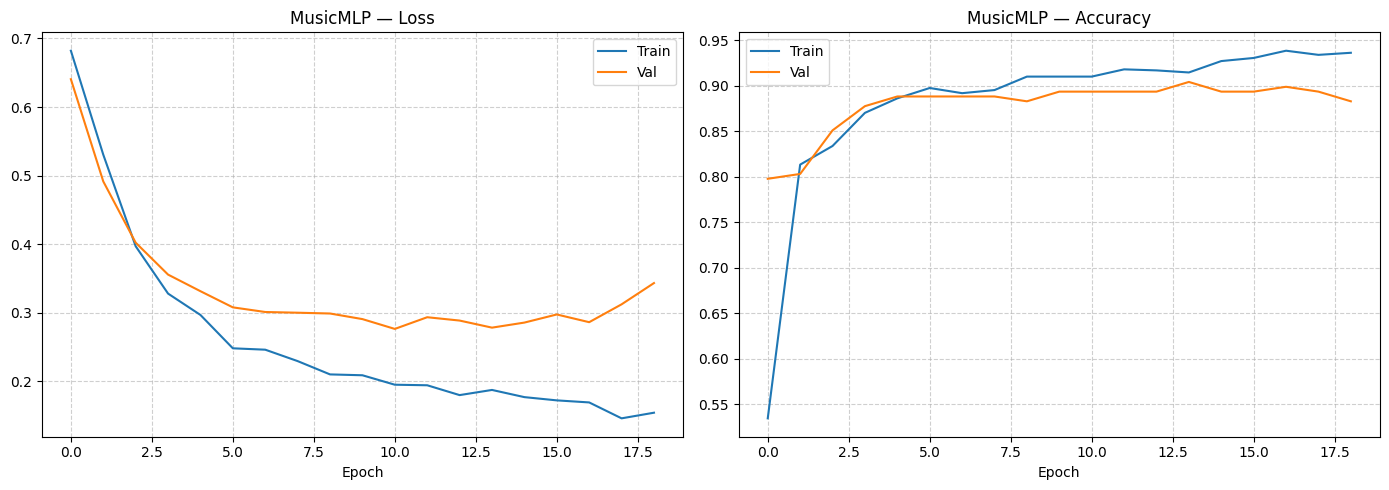


  MusicMLP — Test Results
              precision    recall  f1-score   support

       Human       0.90      0.95      0.93       143
          AI       0.81      0.67      0.73        45

    accuracy                           0.88       188
   macro avg       0.86      0.81      0.83       188
weighted avg       0.88      0.88      0.88       188

ROC AUC: 0.9442


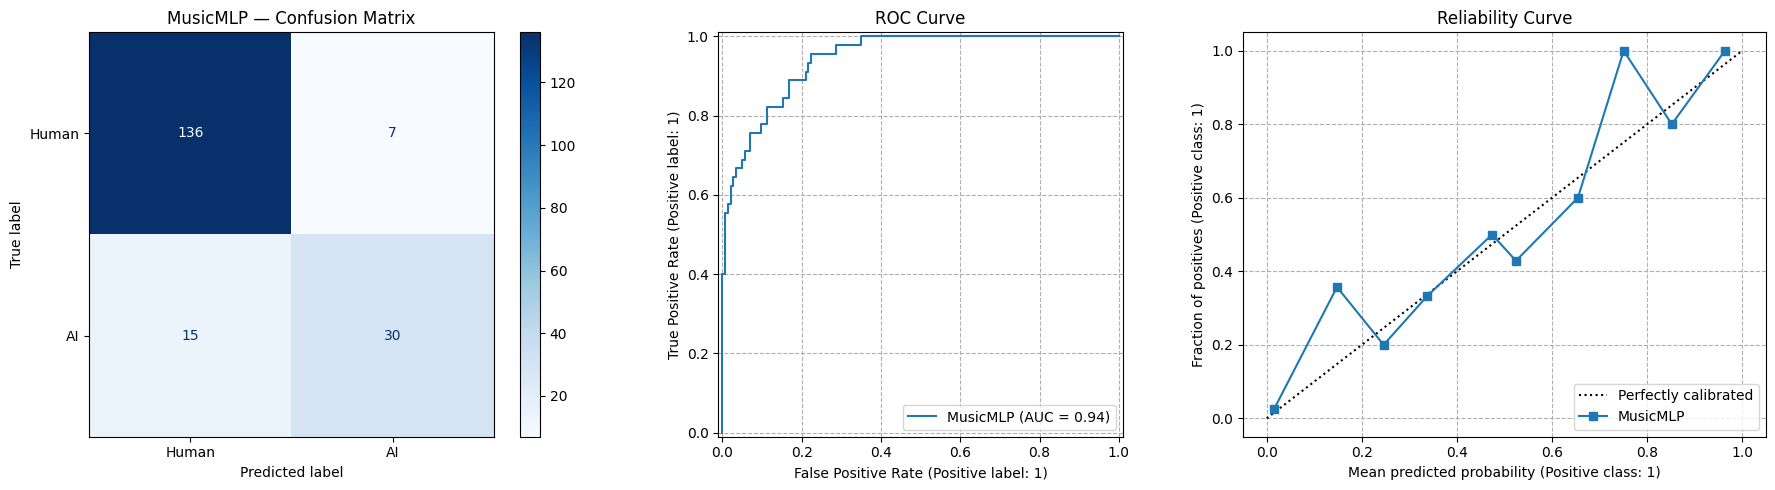

In [24]:
plot_history(mlp_history, title="MusicMLP")
mlp_probs, mlp_labels = evaluate_model(model_mlp, mlp_test, model_name="MusicMLP")

### 5f. Train MusicCNN on raw audio (slower but higher ceiling)

In [ ]:
!pip install -q soundfile pysoundfile
!apt-get -qq install -y libsndfile1
!pip install -q audioread

In [ ]:
!pip uninstall -y pysoundfile soundfile
!pip install -q soundfile==0.12.1

Found existing installation: PySoundFile 0.9.0.post1
Uninstalling PySoundFile-0.9.0.post1:
  Successfully uninstalled PySoundFile-0.9.0.post1
Found existing installation: soundfile 0.13.1
Uninstalling soundfile-0.13.1:
  Successfully uninstalled soundfile-0.13.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 63.5 MB/s eta 0:00:00


In [ ]:
!apt-get -qq install -y ffmpeg

In [ ]:
!apt-get -qq install -y ffmpeg
!pip install -q pydub

In [20]:
import warnings
import librosa

warnings.filterwarnings("ignore", message="PySoundFile failed")
warnings.filterwarnings("ignore", category=FutureWarning, module="librosa")

In [21]:
import json

# Build a filtered df aligned with valid_paths (same as X/y)
valid_df = pd.DataFrame({'path': valid_paths, 'label': y})

# Create two dataset objects — one with augmentation, one without
cnn_ds_train = AudioDataset(valid_df, sr=22050, duration=30.0, n_mels=64, training=True)
cnn_ds_eval  = AudioDataset(valid_df, sr=22050, duration=30.0, n_mels=64, training=False)

n_total   = len(cnn_ds_train)
n_test_c  = int(0.15 * n_total)
n_val_c   = int(0.15 * n_total)
n_train_c = n_total - n_val_c - n_test_c

g = torch.Generator().manual_seed(SEED)
train_idx, val_idx, test_idx = random_split(range(n_total), [n_train_c, n_val_c, n_test_c], generator=g)

# Train uses augmented dataset, val/test use clean dataset
c_train = Subset(cnn_ds_train, train_idx.indices)
c_val   = Subset(cnn_ds_eval,  val_idx.indices)
c_test  = Subset(cnn_ds_eval,  test_idx.indices)

# Verify CNN and MLP test sets cover the same samples
assert len(c_test) == len(test_ds), "Test set sizes don't match — check valid_paths alignment"
assert list(test_idx.indices) == list(test_ds.indices), "Test indices don't match between CNN and MLP"
print("✓ CNN and MLP test sets are aligned")

cnn_train = DataLoader(c_train, batch_size=16, shuffle=True,  num_workers=0, pin_memory=True)
cnn_val   = DataLoader(c_val,   batch_size=16, shuffle=False, num_workers=0, pin_memory=True)
cnn_test  = DataLoader(c_test,  batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

model_cnn = MusicCNN(n_mels=64).to(DEVICE)

CNN_HISTORY_PATH = BASE_DIR + "/cnn_history.json"
CNN_WEIGHTS_PATH = BASE_DIR + "/best_cnn.pt"

if os.path.exists(CNN_WEIGHTS_PATH) and os.path.exists(CNN_HISTORY_PATH):
    print("Found saved CNN weights and history — skipping training.")
    with open(CNN_HISTORY_PATH, "r") as f:
        cnn_history = json.load(f)
    model_cnn.load_state_dict(torch.load(CNN_WEIGHTS_PATH, map_location=DEVICE))
else:
    print("No saved CNN found — training from scratch.")
    cnn_history = train_model(
        model_cnn, cnn_train, cnn_val,
        epochs=40, lr=5e-4, patience=8,
        save_path=CNN_WEIGHTS_PATH
    )
    with open(CNN_HISTORY_PATH, "w") as f:
        json.dump(cnn_history, f)
    print("Saved history to Drive.")

model_cnn.eval()
print("✓ MusicCNN ready.")

✓ CNN and MLP test sets are aligned
Found saved CNN weights and history — skipping training.
✓ MusicCNN ready.


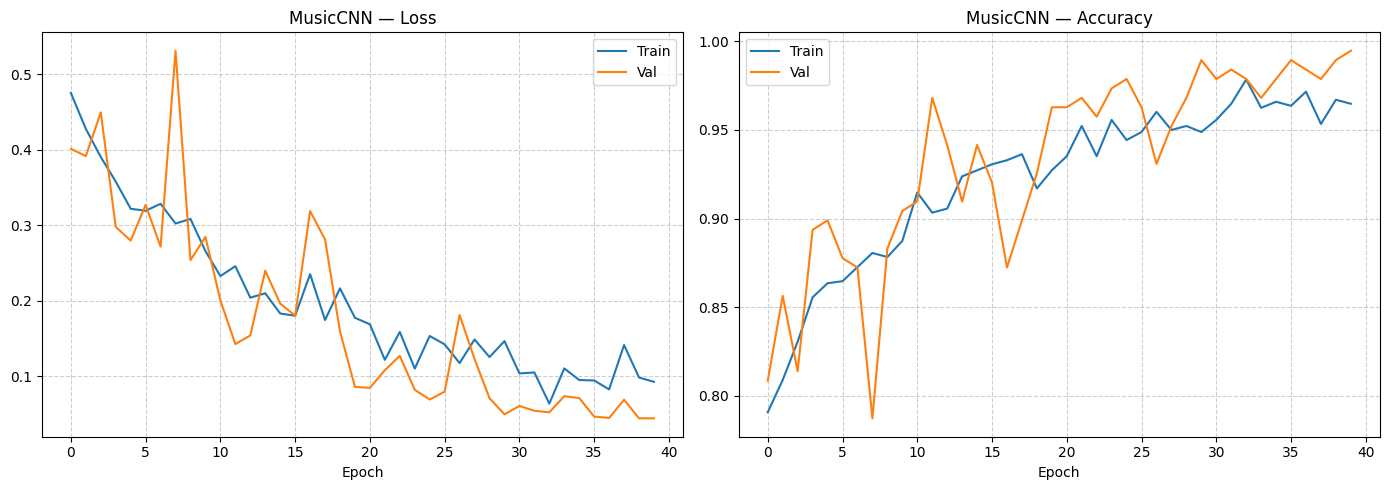


  MusicCNN — Test Results
              precision    recall  f1-score   support

       Human       0.98      1.00      0.99       143
          AI       1.00      0.93      0.97        45

    accuracy                           0.98       188
   macro avg       0.99      0.97      0.98       188
weighted avg       0.98      0.98      0.98       188

ROC AUC: 0.9974


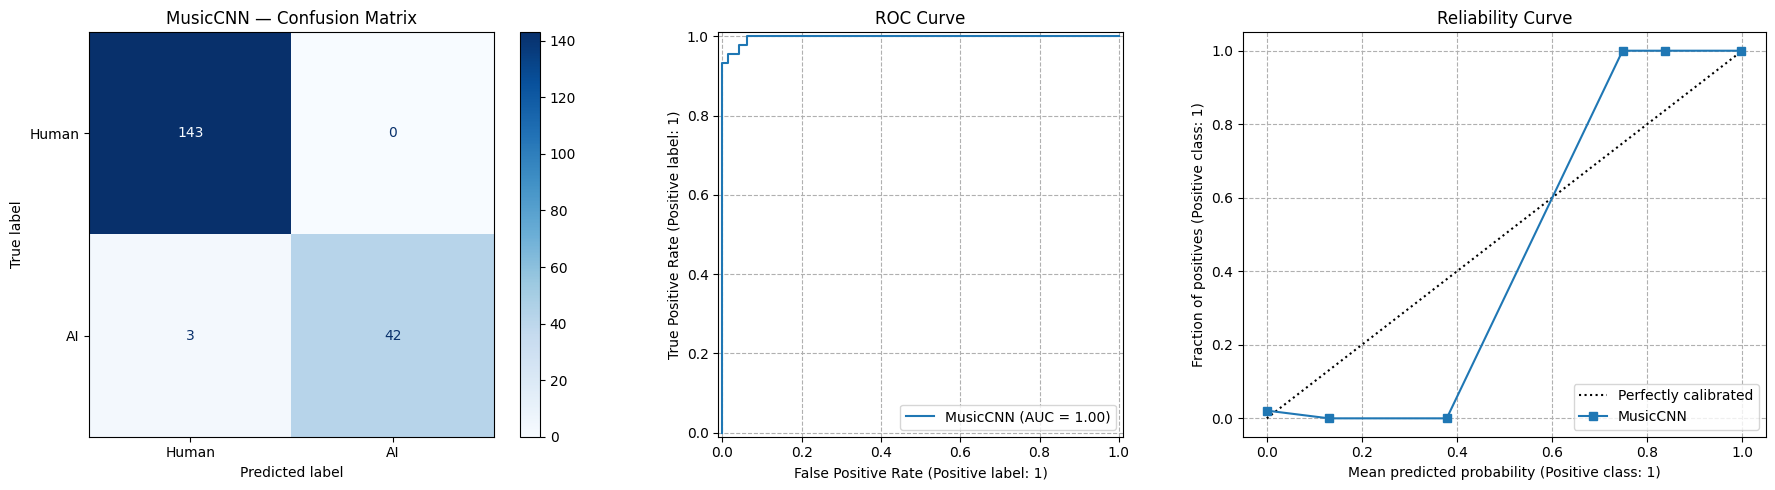

In [22]:
# Load best weights before evaluating
model_cnn.load_state_dict(torch.load(BASE_DIR + "/best_cnn.pt", map_location=DEVICE))
model_cnn.eval()

plot_history(cnn_history, title="MusicCNN")
cnn_probs, cnn_labels = evaluate_model(model_cnn, cnn_test, model_name="MusicCNN")

### 5g. Head-to-head comparison: all models on the same test split

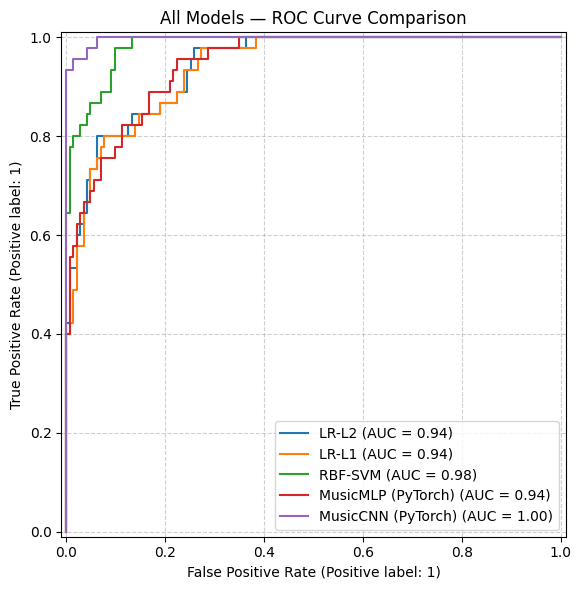

In [25]:
test_idx   = test_ds.indices
X_test_np  = X[test_idx]
y_test_np  = y[test_idx]

fig, ax = plt.subplots(figsize=(9, 6))

for model, name in [(lr_l2, 'LR-L2'), (lr_l1, 'LR-L1'), (svm, 'RBF-SVM')]:
    p = model.predict_proba(X_test_np)[:, 1]
    RocCurveDisplay.from_predictions(y_test_np, p, ax=ax, name=name)

RocCurveDisplay.from_predictions(mlp_labels, mlp_probs, ax=ax, name='MusicMLP (PyTorch)')
RocCurveDisplay.from_predictions(cnn_labels, cnn_probs, ax=ax, name='MusicCNN (PyTorch)')

ax.set_title("All Models — ROC Curve Comparison")
ax.grid(linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

---
# Part 6: Hybrid Audio Mixing Experiment
Mixes human and AI audio at controlled ratios to find the detection threshold —
the key novel contribution of the project.

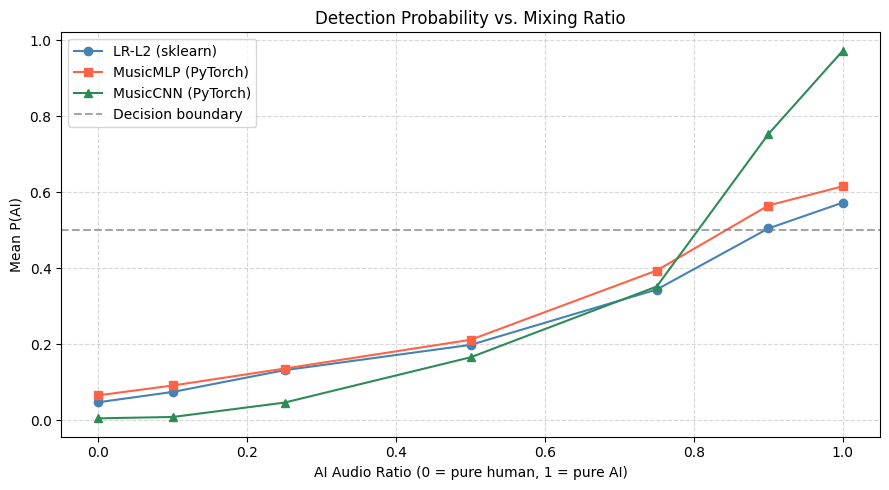

In [26]:
def extract_features_array(y, sr=22050):
    """Same as extract_features() but accepts a raw numpy array instead of a file path."""
    mfccs             = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    spectral_rolloff  = librosa.feature.spectral_rolloff(y=y, sr=sr)
    spectral_flatness = librosa.feature.spectral_flatness(y=y)
    chroma            = librosa.feature.chroma_stft(y=y, sr=sr)
    D                 = librosa.stft(y)
    phase_dev         = np.mean(np.abs(np.diff(np.angle(D), axis=1)))
    return np.hstack([
        np.mean(mfccs, axis=1), np.mean(spectral_centroid),
        np.mean(spectral_rolloff), np.mean(spectral_flatness),
        np.mean(chroma, axis=1), phase_dev,
    ])


def mix_and_predict_sklearn(human_path, ai_path, model, ratios, sr=22050, duration=30.0):
    yh, _ = librosa.load(human_path, sr=sr, duration=duration)
    ya, _ = librosa.load(ai_path,    sr=sr, duration=duration)
    n     = min(len(yh), len(ya))
    yh, ya = yh[:n], ya[:n]

    results = []
    for r in ratios:
        mixed   = (1 - r) * yh + r * ya
        feats   = extract_features_array(mixed, sr).reshape(1, -1)
        prob    = model.predict_proba(feats)[0][1]
        results.append(prob)
    return results


def mix_and_predict_dnn(human_path, ai_path, model, ratios, sr=22050, duration=30.0):
    yh, _ = librosa.load(human_path, sr=sr, duration=duration)
    ya, _ = librosa.load(ai_path,    sr=sr, duration=duration)
    n     = min(len(yh), len(ya))
    yh, ya = yh[:n], ya[:n]

    model.eval()
    results = []
    with torch.no_grad():
        for r in ratios:
            mixed = (1 - r) * yh + r * ya
            feats = torch.tensor(extract_features_array(mixed, sr), dtype=torch.float32)
            prob  = torch.sigmoid(model(feats.unsqueeze(0).to(DEVICE))).item()
            results.append(prob)
    return results


def mix_and_predict_cnn(human_path, ai_path, model, ratios, sr=22050, duration=30.0,
                        n_mels=64, n_fft=1024, hop_length=512):
    """Runs the CNN on mixed audio by computing a mel-spectrogram from the mixed waveform."""
    yh, _ = librosa.load(human_path, sr=sr, duration=duration)
    ya, _ = librosa.load(ai_path,    sr=sr, duration=duration)
    n     = min(len(yh), len(ya))
    yh, ya = yh[:n], ya[:n]

    n_samples = int(sr * duration)

    model.eval()
    results = []
    with torch.no_grad():
        for r in ratios:
            mixed = (1 - r) * yh + r * ya

            # Loudness normalisation (same as AudioDataset)
            target_rms  = 0.1
            current_rms = np.sqrt(np.mean(mixed**2)) + 1e-8
            mixed       = mixed * (target_rms / current_rms)

            if len(mixed) < n_samples:
                mixed = np.pad(mixed, (0, n_samples - len(mixed)))
            else:
                mixed = mixed[:n_samples]

            mel    = librosa.feature.melspectrogram(y=mixed, sr=sr,
                         n_mels=n_mels, n_fft=n_fft, hop_length=hop_length)
            mel_db = librosa.power_to_db(mel, ref=np.max)
            mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)

            spec = torch.tensor(mel_db, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(DEVICE)
            prob = torch.sigmoid(model(spec)).item()
            results.append(prob)
    return results


suno_files_local = glob.glob(SUNO_DRIVE_DIR + "/*.mp3")
fma_files_local  = glob.glob(FMA_DRIVE_DIR  + "/*.mp3")

random.seed(SEED)
pairs  = [(random.choice(fma_files_local), random.choice(suno_files_local))
          for _ in range(10)]
ratios = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]

lr_curves  = []
dnn_curves = []
cnn_curves = []

for human_p, ai_p in pairs:
    try:
        lr_curves.append(mix_and_predict_sklearn(human_p, ai_p, lr_l2,     ratios))
        dnn_curves.append(mix_and_predict_dnn(   human_p, ai_p, model_mlp, ratios))
        cnn_curves.append(mix_and_predict_cnn(   human_p, ai_p, model_cnn, ratios))
    except Exception as e:
        print(f"Skipping pair: {e}")

lr_mean  = np.mean(lr_curves,  axis=0)
dnn_mean = np.mean(dnn_curves, axis=0)
cnn_mean = np.mean(cnn_curves, axis=0)

plt.figure(figsize=(9, 5))
plt.plot(ratios, lr_mean,  'o-', label='LR-L2 (sklearn)',    color='steelblue')
plt.plot(ratios, dnn_mean, 's-', label='MusicMLP (PyTorch)', color='tomato')
plt.plot(ratios, cnn_mean, '^-', label='MusicCNN (PyTorch)', color='seagreen')
plt.axhline(0.5, linestyle='--', color='gray', alpha=0.7, label='Decision boundary')
plt.xlabel("AI Audio Ratio (0 = pure human, 1 = pure AI)")
plt.ylabel("Mean P(AI)")
plt.title("Detection Probability vs. Mixing Ratio")
plt.legend()
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
# Part 7: Error Analysis
Identifies which samples the model is most uncertain about —
useful for understanding failure modes (lo-fi, ambient, etc.).

In [27]:
boundary_idx  = np.argsort(np.abs(mlp_probs - 0.5))[:20]
test_paths_np = valid_paths[test_idx]

boundary_df = pd.DataFrame({
    'file':          test_paths_np[boundary_idx],
    'true_label':    ['Human' if l == 0 else 'AI' for l in mlp_labels[boundary_idx].astype(int)],
    'p_ai':          mlp_probs[boundary_idx].round(3),
    'predicted':     ['Human' if p < 0.5 else 'AI' for p in mlp_probs[boundary_idx]],
    'correct':       mlp_labels[boundary_idx].astype(int) == (mlp_probs[boundary_idx] > 0.5).astype(int),
})
print("20 most uncertain predictions (closest to decision boundary):")
print(boundary_df.to_string(index=False))

20 most uncertain predictions (closest to decision boundary):
                                                   file true_label  p_ai predicted  correct
/content/drive/MyDrive/CS229/fma_subset_1000/067011.mp3      Human 0.501        AI    False
/content/drive/MyDrive/CS229/sunoCaps/-ByoSbgzr4M_1.mp3         AI 0.496     Human    False
/content/drive/MyDrive/CS229/fma_subset_1000/055783.mp3      Human 0.509        AI    False
/content/drive/MyDrive/CS229/fma_subset_1000/024842.mp3      Human 0.490     Human     True
/content/drive/MyDrive/CS229/sunoCaps/0OY8XXZ98rw_4.mp3         AI 0.486     Human    False
/content/drive/MyDrive/CS229/fma_subset_1000/036261.mp3      Human 0.483     Human     True
/content/drive/MyDrive/CS229/sunoCaps/0ZXWSO_Y2C0_1.mp3         AI 0.522        AI     True
/content/drive/MyDrive/CS229/fma_subset_1000/134941.mp3      Human 0.522        AI    False
/content/drive/MyDrive/CS229/sunoCaps/-w8maIWtnUk_4.mp3         AI 0.524        AI     True
/content/drive/MyD

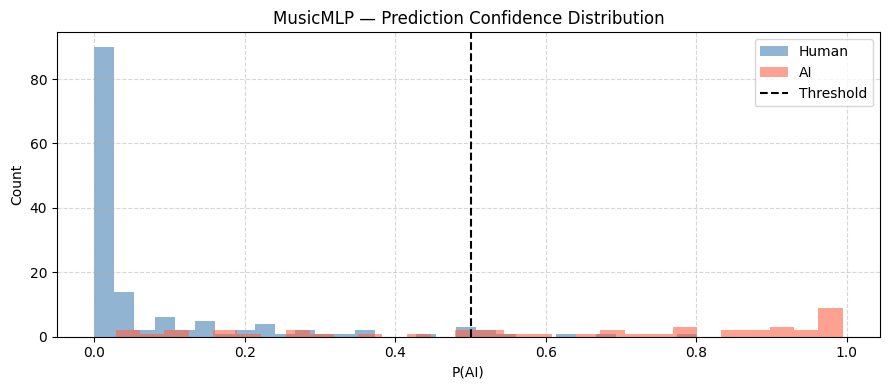

In [28]:
plt.figure(figsize=(9, 4))
plt.hist(mlp_probs[mlp_labels == 0], bins=30, alpha=0.6, label='Human', color='steelblue')
plt.hist(mlp_probs[mlp_labels == 1], bins=30, alpha=0.6, label='AI',    color='tomato')
plt.axvline(0.5, linestyle='--', color='black', label='Threshold')
plt.xlabel("P(AI)")
plt.ylabel("Count")
plt.title("MusicMLP — Prediction Confidence Distribution")
plt.legend()
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

20 most uncertain predictions (closest to decision boundary):
                                                   file true_label  p_ai predicted  correct
/content/drive/MyDrive/CS229/fma_subset_1000/099274.mp3      Human 0.379     Human     True
/content/drive/MyDrive/CS229/sunoCaps/0OY8XXZ98rw_3.mp3         AI 0.748        AI     True
/content/drive/MyDrive/CS229/sunoCaps/2ZfthfWQowE_2.mp3         AI 0.837        AI     True
/content/drive/MyDrive/CS229/fma_subset_1000/148605.mp3      Human 0.131     Human     True
/content/drive/MyDrive/CS229/sunoCaps/15Mw2jyyHk0_3.mp3         AI 0.061     Human    False
/content/drive/MyDrive/CS229/fma_subset_1000/024842.mp3      Human 0.032     Human     True
/content/drive/MyDrive/CS229/sunoCaps/0LLlcPiatiU_4.mp3         AI 0.978        AI     True
/content/drive/MyDrive/CS229/fma_subset_1000/126790.mp3      Human 0.021     Human     True
/content/drive/MyDrive/CS229/sunoCaps/0DYH0sqDXB8_2.mp3         AI 0.980        AI     True
/content/drive/MyD

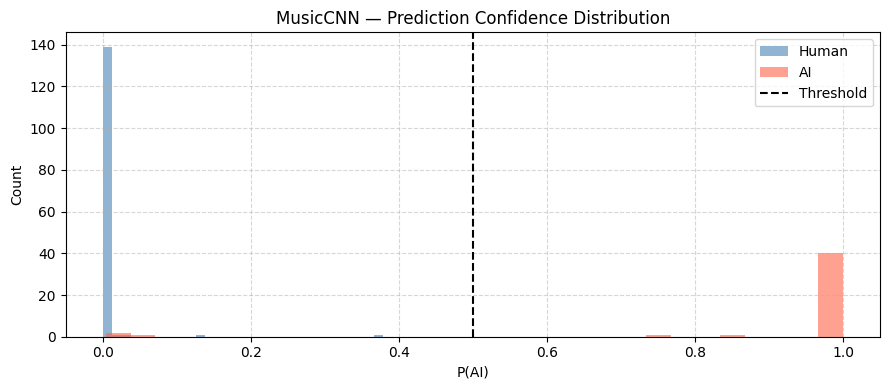

In [29]:
# CNN test set paths — c_test is a Subset of cnn_ds_eval, indices align with valid_paths
cnn_test_paths = valid_paths[test_idx]

boundary_idx = np.argsort(np.abs(cnn_probs - 0.5))[:20]

boundary_df = pd.DataFrame({
    'file':       cnn_test_paths[boundary_idx],
    'true_label': ['Human' if l == 0 else 'AI' for l in cnn_labels[boundary_idx].astype(int)],
    'p_ai':       cnn_probs[boundary_idx].round(3),
    'predicted':  ['Human' if p < 0.5 else 'AI' for p in cnn_probs[boundary_idx]],
    'correct':    cnn_labels[boundary_idx].astype(int) == (cnn_probs[boundary_idx] > 0.5).astype(int),
})
print("20 most uncertain predictions (closest to decision boundary):")
print(boundary_df.to_string(index=False))

plt.figure(figsize=(9, 4))
plt.hist(cnn_probs[cnn_labels == 0], bins=30, alpha=0.6, label='Human', color='steelblue')
plt.hist(cnn_probs[cnn_labels == 1], bins=30, alpha=0.6, label='AI',    color='tomato')
plt.axvline(0.5, linestyle='--', color='black', label='Threshold')
plt.xlabel("P(AI)")
plt.ylabel("Count")
plt.title("MusicCNN — Prediction Confidence Distribution")
plt.legend()
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
# Part 8: Splitting Music


In [30]:
!pip install -q demucs
import demucs
print("Demucs version:", demucs.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.1/87.1 kB 8.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.3/249.3 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 9.0 MB/s eta 0:00:00
Demucs version: 4.0.1


In [31]:
import random, os
random.seed(42)

test_ai    = df[df['label'] == 1]['path'].sample(3, random_state=42).tolist()
test_human = df[df['label'] == 0]['path'].sample(3, random_state=42).tolist()
test_clips = test_ai + test_human

print("Test clips selected:")
for p in test_clips:
    label = "AI" if p in test_ai else "Human"
    print(f"  [{label}]  {os.path.basename(p)}")

Test clips selected:
  [AI]  298Q_pSLflU_1.mp3
  [AI]  07-3grCQ8EU_2.mp3
  [AI]  -cQ-jUTEgck_2.mp3
  [Human]  001193.mp3
  [Human]  109973.mp3
  [Human]  110771.mp3


In [32]:
import subprocess, shutil

SEPARATED_DIR = "/content/separated"
os.makedirs(SEPARATED_DIR, exist_ok=True)

for clip_path in test_clips:
    print(f"\nSeparating: {os.path.basename(clip_path)} ...")
    result = subprocess.run([
        "python", "-m", "demucs",
        "--out",    SEPARATED_DIR,
        "--name",   "htdemucs",
        "--mp3",
        clip_path
    ], capture_output=True, text=True)

    if result.returncode != 0:
        print(f"  ERROR: {result.stderr[-300:]}")
    else:
        print(f"  Done.")

print("\nAll separations complete.")


Separating: 298Q_pSLflU_1.mp3 ...
  Done.

Separating: 07-3grCQ8EU_2.mp3 ...
  Done.

Separating: -cQ-jUTEgck_2.mp3 ...
  Done.

Separating: 001193.mp3 ...
  Done.

Separating: 109973.mp3 ...
  Done.

Separating: 110771.mp3 ...
  Done.

All separations complete.


In [33]:
from pathlib import Path

def find_stems(clip_path, separated_dir=SEPARATED_DIR):
    """Returns a dict of stem_name -> path for a given clip."""
    track_name = Path(clip_path).stem
    stem_dir   = Path(separated_dir) / "htdemucs" / track_name

    if not stem_dir.exists():
        print(f"  No stems found for {track_name} — check separation step.")
        return {}

    stems = {p.stem: str(p) for p in stem_dir.iterdir()
             if p.suffix in (".wav", ".mp3")}
    return stems

for clip in test_clips:
    label = "AI" if clip in test_ai else "Human"
    stems = find_stems(clip)
    print(f"\n[{label}] {Path(clip).stem}")
    for stem_name, stem_path in stems.items():
        size_mb = os.path.getsize(stem_path) / 1e6
        print(f"  {stem_name:<10} {stem_path}  ({size_mb:.1f} MB)")


[AI] 298Q_pSLflU_1
  vocals     /content/separated/htdemucs/298Q_pSLflU_1/vocals.mp3  (3.4 MB)
  other      /content/separated/htdemucs/298Q_pSLflU_1/other.mp3  (3.4 MB)
  bass       /content/separated/htdemucs/298Q_pSLflU_1/bass.mp3  (3.4 MB)
  drums      /content/separated/htdemucs/298Q_pSLflU_1/drums.mp3  (3.4 MB)

[AI] 07-3grCQ8EU_2
  vocals     /content/separated/htdemucs/07-3grCQ8EU_2/vocals.mp3  (3.5 MB)
  other      /content/separated/htdemucs/07-3grCQ8EU_2/other.mp3  (3.5 MB)
  bass       /content/separated/htdemucs/07-3grCQ8EU_2/bass.mp3  (3.5 MB)
  drums      /content/separated/htdemucs/07-3grCQ8EU_2/drums.mp3  (3.5 MB)

[AI] -cQ-jUTEgck_2
  vocals     /content/separated/htdemucs/-cQ-jUTEgck_2/vocals.mp3  (3.8 MB)
  other      /content/separated/htdemucs/-cQ-jUTEgck_2/other.mp3  (3.8 MB)
  bass       /content/separated/htdemucs/-cQ-jUTEgck_2/bass.mp3  (3.8 MB)
  drums      /content/separated/htdemucs/-cQ-jUTEgck_2/drums.mp3  (3.8 MB)

[Human] 001193
  vocals     /content/se

In [34]:
from IPython.display import Audio, display

def audition_stems(clip_path, label=""):
    stems = find_stems(clip_path)
    if not stems:
        return

    print(f"\n{'='*55}")
    print(f"  [{label}]  {Path(clip_path).stem}")
    print(f"{'='*55}")

    print("\n  ── Original clip ──")
    display(Audio(clip_path))

    for stem_name in ["vocals", "drums", "bass", "other"]:
        if stem_name in stems:
            print(f"\n  ── {stem_name.capitalize()} stem ──")
            display(Audio(stems[stem_name]))

audition_stems(test_ai[0],    label="AI")
audition_stems(test_human[0], label="Human")

Output hidden; open in https://colab.research.google.com to view.

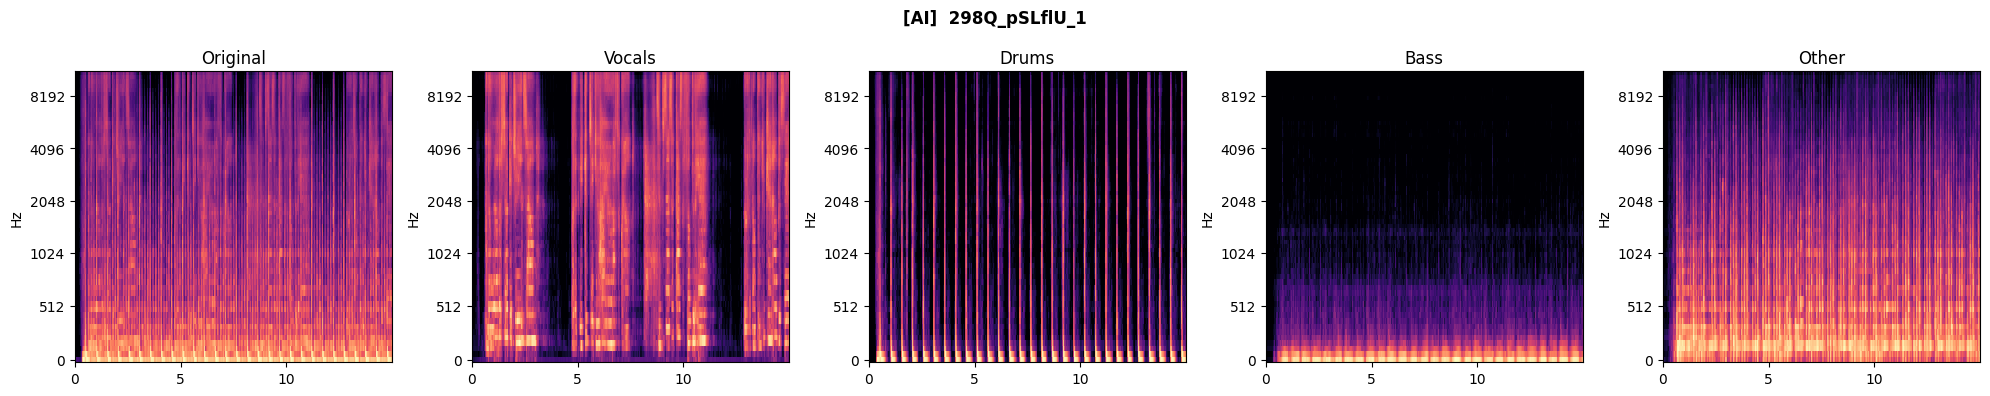

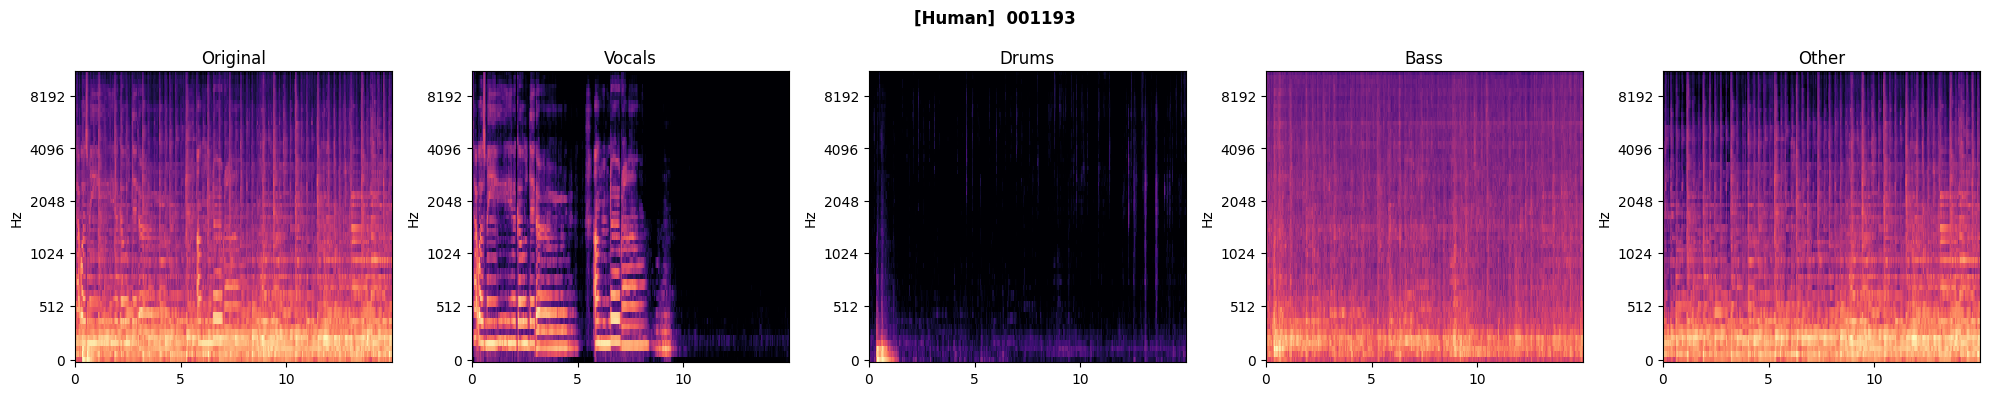

In [35]:
import librosa, librosa.display, numpy as np
import matplotlib.pyplot as plt

def plot_stem_spectrograms(clip_path, label="", sr=22050):
    stems = find_stems(clip_path)
    if not stems:
        return

    stem_order = [s for s in ["vocals", "drums", "bass", "other"] if s in stems]
    n = len(stem_order) + 1

    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    fig.suptitle(f"[{label}]  {Path(clip_path).stem}", fontsize=12, fontweight='bold')

    def plot_spec(ax, path, title):
        y, _ = librosa.load(path, sr=sr, duration=15.0)
        S    = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
        S_db = librosa.power_to_db(S, ref=np.max)
        librosa.display.specshow(S_db, sr=sr, ax=ax, x_axis='time', y_axis='mel')
        ax.set_title(title)
        ax.set_xlabel("")

    plot_spec(axes[0], clip_path, "Original")
    for i, stem_name in enumerate(stem_order):
        plot_spec(axes[i + 1], stems[stem_name], stem_name.capitalize())

    plt.tight_layout()
    plt.show()

plot_stem_spectrograms(test_ai[0],    label="AI")
plot_stem_spectrograms(test_human[0], label="Human")

In [36]:
def bleed_ratio(stem_path, stem_name, sr=22050):
    """
    Estimates separation quality by checking how much energy falls
    outside the expected frequency range for that stem type.
    Returns a value 0-1. Lower = cleaner separation.
    """
    expected_ranges = {
        "vocals": (200,  4000),
        "drums":  (50,   8000),
        "bass":   (40,    400),
        "other":  (200,  8000),
    }

    if stem_name not in expected_ranges:
        return None

    y, _ = librosa.load(stem_path, sr=sr, duration=15.0)
    S    = np.abs(librosa.stft(y))
    freqs = librosa.fft_frequencies(sr=sr)

    lo, hi = expected_ranges[stem_name]
    in_range  = ((freqs >= lo) & (freqs <= hi))

    energy_in  = S[in_range,  :].sum()
    energy_out = S[~in_range, :].sum()
    total      = energy_in + energy_out + 1e-8

    return float(energy_out / total)

print(f"{'Clip':<30} {'Label':<8} {'Vocals':>8} {'Drums':>8} {'Bass':>8} {'Other':>8}")
print("─" * 72)

for clip in test_clips:
    label = "AI" if clip in test_ai else "Human"
    stems = find_stems(clip)
    name  = Path(clip).stem[:28]
    scores = []
    for stem_name in ["vocals", "drums", "bass", "other"]:
        if stem_name in stems:
            ratio = bleed_ratio(stems[stem_name], stem_name)
            scores.append(f"{ratio:.3f}")
        else:
            scores.append("  N/A")
    print(f"{name:<30} {label:<8} {'  '.join(scores)}")

print("\nInterpretation: values < 0.15 = clean, 0.15–0.30 = acceptable, > 0.30 = heavy bleed")

Clip                           Label      Vocals    Drums     Bass    Other
────────────────────────────────────────────────────────────────────────
298Q_pSLflU_1                  AI       0.556  0.151  0.216  0.302
07-3grCQ8EU_2                  AI       0.300  0.297  0.831  0.723
-cQ-jUTEgck_2                  AI       0.283  0.157  0.057  0.167
001193                         Human    0.277  0.170  0.639  0.290
109973                         Human    0.410  0.096  0.429  0.289
110771                         Human    0.176  0.124  0.127  0.113

Interpretation: values < 0.15 = clean, 0.15–0.30 = acceptable, > 0.30 = heavy bleed


In [37]:
RELIABLE_STEMS = ["vocals", "drums", "other"]

def classify_stems(clip_path, model, device):
    stems = find_stems(clip_path)
    results = {}
    for stem_name in RELIABLE_STEMS:
        if stem_name not in stems:
            continue
        features = extract_features(stems[stem_name])
        if features is not None:
            x    = torch.tensor(features, dtype=torch.float32).unsqueeze(0).to(device)
            prob = torch.sigmoid(model(x)).item()
            results[stem_name] = prob
    return results

In [38]:
BLEED_THRESHOLD = 0.35

def classify_stems_with_qc(clip_path, model, device):
    stems   = find_stems(clip_path)
    results = {}

    for stem_name in RELIABLE_STEMS:
        if stem_name not in stems:
            continue

        bleed = bleed_ratio(stems[stem_name], stem_name)

        if bleed > BLEED_THRESHOLD:
            results[stem_name] = {
                "p_ai":     None,
                "label":    "Unreliable",
                "bleed":    bleed,
                "note":     f"Bleed ratio {bleed:.2f} exceeds threshold — skip"
            }
            continue

        features = extract_features(stems[stem_name])
        if features is not None:
            x    = torch.tensor(features, dtype=torch.float32).unsqueeze(0).to(device)
            prob = torch.sigmoid(model(x)).item()
            results[stem_name] = {
                "p_ai":  prob,
                "label": "AI" if prob > 0.5 else "Human",
                "bleed": bleed,
                "note":  ""
            }

    return results

In [39]:
def extract_features_with_bleed(stem_path, stem_name):
    base_features = extract_features(stem_path)
    bleed         = bleed_ratio(stem_path, stem_name)
    return np.append(base_features, bleed)

In [40]:
import subprocess, os, glob
from pathlib import Path

SEPARATED_DIR  = BASE_DIR + "/separated_stems"
STEM_MANIFEST  = BASE_DIR + "/stem_manifest.csv"
RELIABLE_STEMS = ["vocals", "drums", "other"]
BLEED_THRESHOLD = 0.35

os.makedirs(SEPARATED_DIR, exist_ok=True)

already_done = set(
    p.parent.name
    for p in Path(SEPARATED_DIR).glob("htdemucs/**/vocals.*")
)
clips_to_run = [p for p in df['path'].tolist() if Path(p).stem not in already_done]

print(f"Already separated: {len(already_done)}")
print(f"Remaining:         {len(clips_to_run)}")
print(f"Estimated time:    ~{len(clips_to_run) * 3 // 60} min on GPU, ~{len(clips_to_run) * 4 // 60} min on CPU")

Already separated: 1255
Remaining:         0
Estimated time:    ~0 min on GPU, ~0 min on CPU


In [41]:
failed = []

for i, clip_path in enumerate(clips_to_run):
    print(f"[{i+1}/{len(clips_to_run)}] {Path(clip_path).name}", end=" ... ")

    result = subprocess.run([
        sys.executable, "-m", "demucs",
        "--out",    SEPARATED_DIR,
        "--name",   "htdemucs",
        "--mp3",
        "--device", "cuda",
        clip_path
    ], capture_output=True, text=True)

    if result.returncode != 0:
        print("FAILED")
        failed.append(clip_path)
    else:
        print("ok")

print(f"\nDone. Failed: {len(failed)}")
if failed:
    print("Failed clips:", failed)


Done. Failed: 0


In [42]:
import sys
!{sys.executable} -m pip install -q demucs
import importlib
importlib.invalidate_caches()
import demucs
print("✓ Demucs installed at:", demucs.__file__)

✓ Demucs installed at: /usr/local/lib/python3.12/dist-packages/demucs/__init__.py


In [43]:
import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

DEVICE: cuda


In [44]:
stem_root = Path(SEPARATED_DIR) / "htdemucs"
folders   = list(stem_root.iterdir())
complete  = [f for f in folders if len(list(f.glob("*.mp3"))) >= 3]
partial   = [f for f in folders if 0 < len(list(f.glob("*.mp3"))) < 3]

print(f"Tracks fully separated:  {len(complete)}")
print(f"Tracks partial/broken:   {len(partial)}")
print(f"Total Drive space used:  {sum(f.stat().st_size for f in stem_root.rglob('*.mp3')) / 1e9:.1f} GB")

Tracks fully separated:  1255
Tracks partial/broken:   0
Total Drive space used:  8.8 GB


In [45]:
import librosa

RELIABLE_STEMS  = ["vocals", "drums", "other"]
BLEED_THRESHOLD = 0.35

def find_stems(clip_path, separated_dir=SEPARATED_DIR):
    track_name = Path(clip_path).stem
    stem_dir   = Path(separated_dir) / "htdemucs" / track_name
    if not stem_dir.exists():
        return {}
    return {p.stem: str(p) for p in stem_dir.iterdir() if p.suffix in (".wav", ".mp3")}

def bleed_ratio(stem_path, stem_name, sr=22050):
    expected_ranges = {
        "vocals": (200,  4000),
        "drums":  (50,   8000),
        "other":  (200,  8000),
    }
    if stem_name not in expected_ranges:
        return 1.0
    y, _ = librosa.load(stem_path, sr=sr, duration=15.0)
    S     = np.abs(librosa.stft(y))
    freqs = librosa.fft_frequencies(sr=sr)
    lo, hi = expected_ranges[stem_name]
    in_range = (freqs >= lo) & (freqs <= hi)
    energy_out = S[~in_range, :].sum()
    total      = S.sum() + 1e-8
    return float(energy_out / total)

def extract_features(file_path):
    try:
        y, sr = librosa.load(file_path, sr=22050, duration=30.0)
        mfccs             = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        spectral_rolloff  = librosa.feature.spectral_rolloff(y=y, sr=sr)
        spectral_flatness = librosa.feature.spectral_flatness(y=y)
        chroma            = librosa.feature.chroma_stft(y=y, sr=sr)
        D                 = librosa.stft(y)
        phase_dev         = np.mean(np.abs(np.diff(np.angle(D), axis=1)))
        return np.hstack([
            np.mean(mfccs, axis=1),
            np.mean(spectral_centroid),
            np.mean(spectral_rolloff),
            np.mean(spectral_flatness),
            np.mean(chroma, axis=1),
            phase_dev,
        ])
    except Exception as e:
        print(f"Error: {file_path} → {e}")
        return None

In [46]:
STEM_MANIFEST = BASE_DIR + "/stem_manifest.csv"

if os.path.exists(STEM_MANIFEST):
    print("Found saved manifest — loading.")
    stem_df = pd.read_csv(STEM_MANIFEST)
else:
    print("Building stem manifest...")
    rows = []

    for _, row in df.iterrows():
        stems = find_stems(row['path'])
        if not stems:
            continue

        for stem_name in RELIABLE_STEMS:
            if stem_name not in stems:
                continue
            try:
                bleed = bleed_ratio(stems[stem_name], stem_name)
            except Exception:
                bleed = 1.0

            rows.append({
                "stem_path":  stems[stem_name],
                "track_name": Path(row['path']).stem,
                "stem_name":  stem_name,
                "label":      row['label'],
                "bleed":      round(bleed, 4),
                "reliable":   bleed <= BLEED_THRESHOLD,
            })

    stem_df = pd.DataFrame(rows)
    stem_df.to_csv(STEM_MANIFEST, index=False)
    print(f"Saved manifest: {len(stem_df)} total stems")

reliable_df = stem_df[stem_df['reliable']].reset_index(drop=True)

print(f"\nTotal stems:           {len(stem_df)}")
print(f"Reliable stems:        {len(reliable_df)}")
print(f"Dropped (high bleed):  {len(stem_df) - len(reliable_df)}")
print(f"\nBreakdown by stem type:")
print(reliable_df.groupby(['stem_name', 'label']).size().unstack(fill_value=0).rename(columns={0:'Human', 1:'AI'}))

Found saved manifest — loading.

Total stems:           3765
Reliable stems:        2938
Dropped (high bleed):  827

Breakdown by stem type:
label      Human   AI
stem_name            
drums        957  185
other        924  192
vocals       576  104


In [47]:
STEM_FEATURES_PATH = BASE_DIR + "/X_stem_features.npy"
STEM_LABELS_PATH   = BASE_DIR + "/y_stem_labels.npy"
STEM_META_PATH     = BASE_DIR + "/stem_meta.csv"

if os.path.exists(STEM_FEATURES_PATH):
    print("Found saved stem features — loading.")
    X_stem  = np.load(STEM_FEATURES_PATH)
    y_stem  = np.load(STEM_LABELS_PATH)
    meta_df = pd.read_csv(STEM_META_PATH)
else:
    print(f"Extracting features from {len(reliable_df)} stems...")
    features_list, valid_idx = [], []

    for i, row in reliable_df.iterrows():
        if i % 200 == 0:
            print(f"  {i}/{len(reliable_df)}")
        feats = extract_features(row['stem_path'])
        if feats is not None:
            feats = np.append(feats, row['bleed'])
            features_list.append(feats)
            valid_idx.append(i)

    X_stem  = np.array(features_list)
    y_stem  = reliable_df['label'].iloc[valid_idx].values
    meta_df = reliable_df.iloc[valid_idx].reset_index(drop=True)

    np.save(STEM_FEATURES_PATH, X_stem)
    np.save(STEM_LABELS_PATH,   y_stem)
    meta_df.to_csv(STEM_META_PATH, index=False)
    print(f"Saved. Shape: {X_stem.shape}")

print(f"\nX_stem: {X_stem.shape}  |  AI: {y_stem.sum()}  Human: {(y_stem==0).sum()}")

Found saved stem features — loading.

X_stem: (2938, 30)  |  AI: 481  Human: 2457


Build MLP for Stemmed Data

 Epoch | Train Loss | Train Acc | Val Loss | Val Acc
───────────────────────────────────────────────────────
     1 |     0.6269 |   62.10% |   0.4763 | 83.64%  ✓
     2 |     0.4522 |   82.80% |   0.4056 | 83.64%  ✓
     3 |     0.3861 |   83.28% |   0.3492 | 85.45%  ✓
     4 |     0.3478 |   84.74% |   0.3198 | 85.91%  ✓
     5 |     0.3211 |   86.20% |   0.3119 | 84.77%  ✓
     6 |     0.3014 |   87.71% |   0.3332 | 84.32%
     7 |     0.2931 |   88.14% |   0.2790 | 88.18%  ✓
     8 |     0.2790 |   88.00% |   0.2760 | 87.73%  ✓
     9 |     0.2580 |   89.36% |   0.2788 | 88.18%
    10 |     0.2581 |   88.87% |   0.2689 | 88.18%  ✓
    11 |     0.2483 |   89.07% |   0.2596 | 88.86%  ✓
    12 |     0.2318 |   91.16% |   0.2633 | 89.32%
    13 |     0.2395 |   90.23% |   0.2527 | 90.00%  ✓
    14 |     0.2332 |   89.89% |   0.2512 | 89.32%  ✓
    15 |     0.2338 |   90.38% |   0.2482 | 90.00%  ✓
    16 |     0.2172 |   91.25% |   0.2622 | 88.18%
    17 |     0.2134 |   90.91% |   0.24

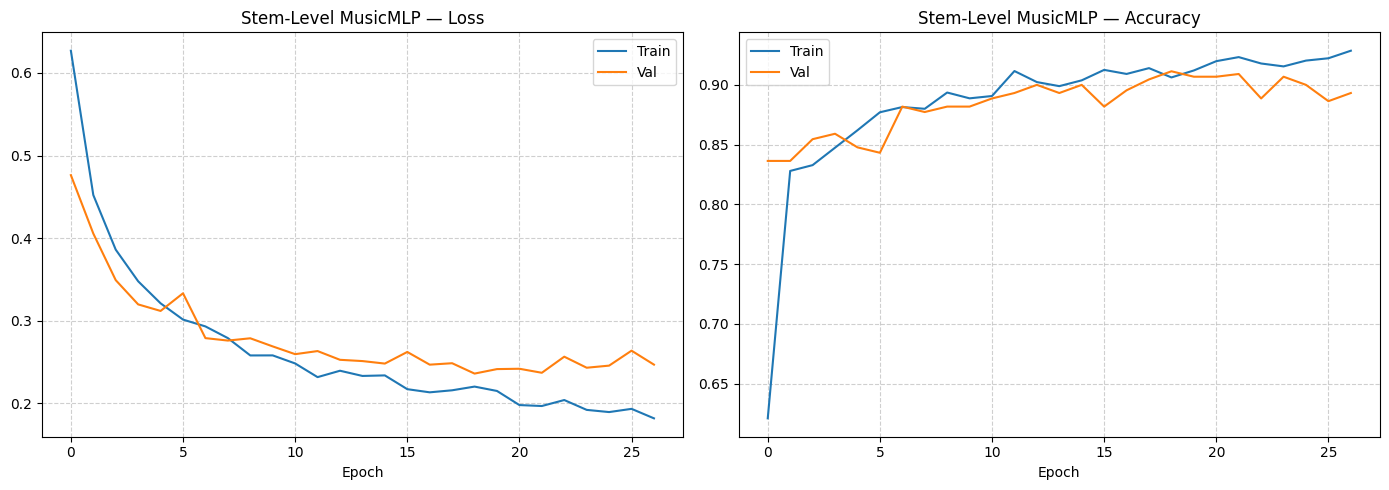


  Stem MusicMLP — Test Results
              precision    recall  f1-score   support

       Human       0.95      0.97      0.96       385
          AI       0.75      0.65      0.70        55

    accuracy                           0.93       440
   macro avg       0.85      0.81      0.83       440
weighted avg       0.93      0.93      0.93       440

ROC AUC: 0.9209


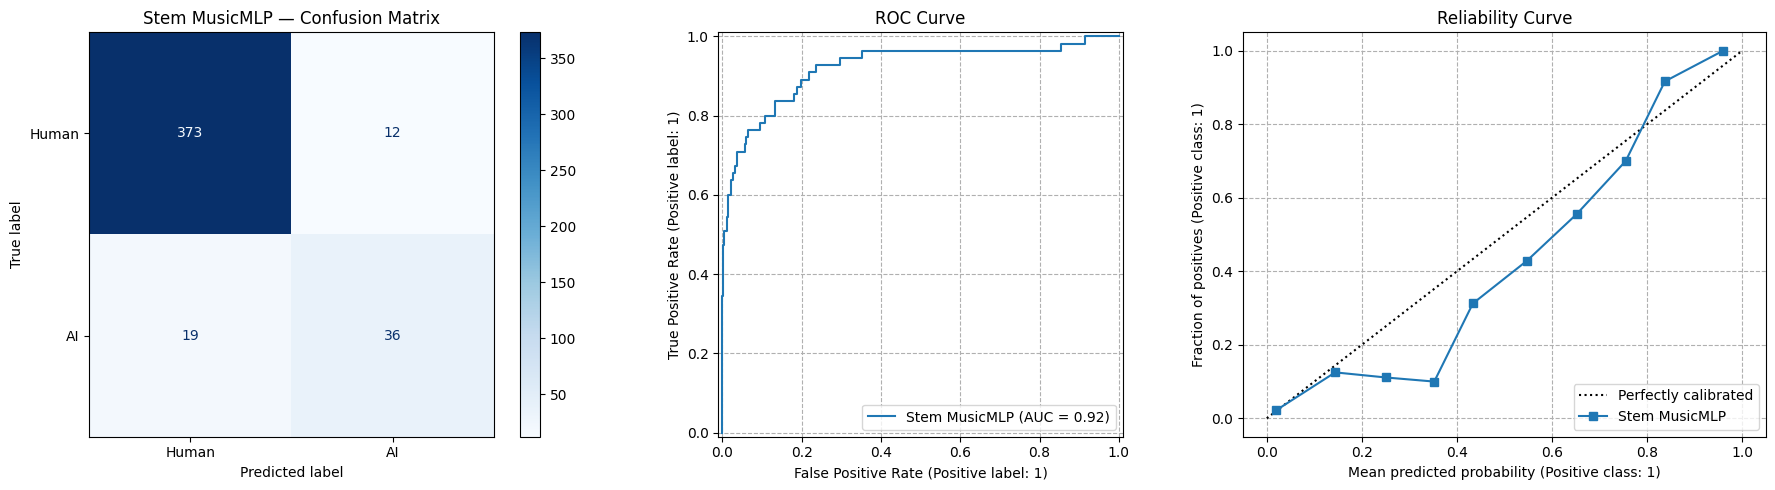

In [48]:
from torch.utils.data import random_split, DataLoader
import torch.nn as nn

stem_dataset = FeatureDataset(X_stem, y_stem)
n_test  = int(0.15 * len(stem_dataset))
n_val   = int(0.15 * len(stem_dataset))
n_train = len(stem_dataset) - n_val - n_test
g       = torch.Generator().manual_seed(SEED)
train_ds, val_ds, test_ds = random_split(
    stem_dataset, [n_train, n_val, n_test], generator=g)

stem_train = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=2)
stem_val   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=2)
stem_test  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=2)

model_stem = MusicMLP(input_dim=30).to(DEVICE)

stem_history = train_model(
    model_stem, stem_train, stem_val,
    epochs=60, lr=1e-3, patience=8,
    save_path=BASE_DIR + "/best_stem_mlp.pt"
)

plot_history(stem_history, title="Stem-Level MusicMLP")
stem_probs, stem_labels_out = evaluate_model(
    model_stem, stem_test, model_name="Stem MusicMLP")

Per-stem-type results:

Stem         Accuracy      AUC     N_AI  N_Human
──────────────────────────────────────────────
vocals          0.951    0.965       10       93
drums           0.914    0.920       27      147
other           0.933    0.901       18      145


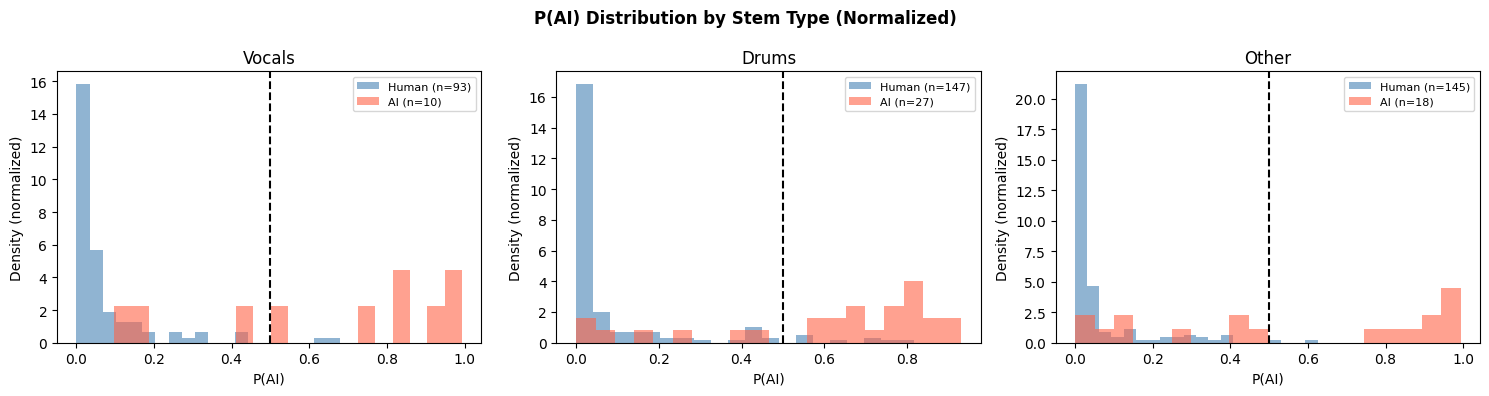

In [49]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

test_meta = meta_df.iloc[test_ds.indices].reset_index(drop=True)

results_df = test_meta.copy()
results_df['p_ai']      = stem_probs
results_df['predicted'] = (stem_probs > 0.5).astype(int)
results_df['correct']   = (results_df['predicted'] == results_df['label'])

print("Per-stem-type results:\n")
print(f"{'Stem':<10} {'Accuracy':>10} {'AUC':>8} {'N_AI':>8} {'N_Human':>8}")
print("─" * 46)
for stem_name in RELIABLE_STEMS:
    sub = results_df[results_df['stem_name'] == stem_name]
    if len(sub) == 0:
        continue
    acc = sub['correct'].mean()
    auc = roc_auc_score(sub['label'], sub['p_ai'])
    n_ai    = (sub['label'] == 1).sum()
    n_human = (sub['label'] == 0).sum()
    print(f"{stem_name:<10} {acc:>10.3f} {auc:>8.3f} {n_ai:>8} {n_human:>8}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, stem_name in enumerate(RELIABLE_STEMS):
    sub     = results_df[results_df['stem_name'] == stem_name]
    human   = sub[sub['label'] == 0]['p_ai']
    ai      = sub[sub['label'] == 1]['p_ai']

    axes[i].hist(human, bins=20, alpha=0.6, label=f'Human (n={len(human)})',
                 color='steelblue', density=True)
    axes[i].hist(ai,    bins=20, alpha=0.6, label=f'AI (n={len(ai)})',
                 color='tomato',    density=True)

    axes[i].axvline(0.5, linestyle='--', color='black', linewidth=1.5)
    axes[i].set_title(f"{stem_name.capitalize()}")
    axes[i].set_xlabel("P(AI)")
    axes[i].set_ylabel("Density (normalized)")
    axes[i].legend(fontsize=8)

plt.suptitle("P(AI) Distribution by Stem Type (Normalized)", fontweight='bold')
plt.tight_layout()
plt.show()

In [50]:
class StemMusicCNN(nn.Module):
    """CNN over stem mel-spectrograms, conditioned on stem type via one-hot."""
    def __init__(self, n_mels=64, dropout=0.4, n_stem_types=3):
        super().__init__()
        self.stem_conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=(2,1), padding=1, bias=False),
            nn.BatchNorm2d(32), nn.GELU(),
        )
        self.res1    = ResidualBlock(32,  dropout=0.1)
        self.pool1   = nn.MaxPool2d(2)
        self.expand2 = nn.Conv2d(32, 64, 1, bias=False)
        self.res2    = ResidualBlock(64,  dropout=0.1)
        self.pool2   = nn.MaxPool2d(2)
        self.expand3 = nn.Conv2d(64, 128, 1, bias=False)
        self.res3    = ResidualBlock(128, dropout=0.1)
        self.gap     = nn.AdaptiveAvgPool2d(1)
        # head takes CNN features (128) + stem one-hot (n_stem_types)
        self.head    = nn.Sequential(
            nn.Linear(128 + n_stem_types, 64), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x, stem_onehot):
        x = self.stem_conv(x)
        x = self.pool1(self.res1(x))
        x = self.pool2(self.res2(self.expand2(x)))
        x = self.gap(self.res3(self.expand3(x)))
        x = x.flatten(1)                        # (B, 128)
        x = torch.cat([x, stem_onehot], dim=1)  # (B, 128 + 3)
        return self.head(x).squeeze(-1)


def train_epoch_stem(model, loader, optimizer, criterion):
    model.train()
    total_loss = correct = n = 0
    for spec, onehot, yb in loader:
        spec, onehot, yb = spec.to(DEVICE), onehot.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(spec, onehot)
        loss   = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(yb)
        correct    += ((torch.sigmoid(logits) > 0.5).float() == yb).sum().item()
        n          += len(yb)
    return total_loss / n, correct / n


@torch.no_grad()
def eval_epoch_stem(model, loader, criterion):
    model.eval()
    total_loss = correct = n = 0
    all_probs, all_labels, all_stems = [], [], []
    for spec, onehot, yb in loader:
        spec, onehot, yb = spec.to(DEVICE), onehot.to(DEVICE), yb.to(DEVICE)
        logits = model(spec, onehot)
        probs  = torch.sigmoid(logits)
        total_loss += criterion(logits, yb).item() * len(yb)
        correct    += ((probs > 0.5).float() == yb).sum().item()
        n          += len(yb)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())
        all_stems.extend(onehot.argmax(dim=1).cpu().numpy())
    return total_loss / n, correct / n, np.array(all_probs), np.array(all_labels), np.array(all_stems)


def train_model_stem(model, train_loader, val_loader, epochs=50, lr=1e-3,
                     weight_decay=1e-3, patience=8, save_path="best_stem_cnn.pt"):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr / 20)

    best_val_loss = float('inf')
    patience_ctr  = 0
    history       = dict(train_loss=[], val_loss=[], train_acc=[], val_acc=[])

    print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7}")
    print("─" * 55)

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc          = train_epoch_stem(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc, _, _, _ = eval_epoch_stem(model, val_loader, criterion)
        scheduler.step()

        for k, v in zip(history, [tr_loss, vl_loss, tr_acc, vl_acc]):
            history[k].append(v)

        tag = ""
        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            patience_ctr  = 0
            torch.save(model.state_dict(), save_path)
            tag = "  ✓"
        else:
            patience_ctr += 1

        print(f"{epoch:>6} | {tr_loss:>10.4f} | {tr_acc:>8.2%} | {vl_loss:>8.4f} | {vl_acc:>6.2%}{tag}")

        if patience_ctr >= patience:
            print(f"\nEarly stop at epoch {epoch}.")
            break

    model.load_state_dict(torch.load(save_path, map_location=DEVICE))
    print(f"Best model restored from {save_path}")
    return history

In [51]:
import json

class StemAudioDataset(Dataset):
    STEM_TYPES = ["vocals", "drums", "other"]

    def __init__(self, df, sr=22050, duration=15.0, n_mels=64,
                 n_fft=1024, hop_length=512, training=False,
                 cache_dir=None):
        self.labels     = df['label'].values
        self.stem_names = df['stem_name'].values
        self.paths      = df['stem_path'].values
        self.sr         = sr
        self.n_samples  = int(sr * duration)
        self.n_mels     = n_mels
        self.n_fft      = n_fft
        self.hop_length = hop_length
        self.training   = training
        self.cache_dir  = cache_dir
        self.ram_cache  = {}

        if cache_dir:
            os.makedirs(cache_dir, exist_ok=True)
            self._build_disk_cache()
            self._load_into_ram()

    def _build_disk_cache(self):
        missing = [i for i in range(len(self.paths))
                   if not os.path.exists(self._cache_path(i))]
        if not missing:
            print(f"Disk cache complete — {len(self.paths)} spectrograms ready.")
            return
        print(f"Caching {len(missing)} spectrograms to disk...")
        for count, i in enumerate(missing):
            try:
                spec = self._compute_spectrogram(self.paths[i])
            except Exception as e:
                print(f"  Cache error [{i}] {self.paths[i]}: {e}")
                T    = self.n_samples // self.hop_length + 1
                spec = torch.zeros(1, self.n_mels, T)
            torch.save(spec, self._cache_path(i))
            if (count + 1) % 500 == 0:
                print(f"  {count + 1}/{len(missing)} cached...")
        print("Disk caching complete.")

    def _load_into_ram(self):
        print(f"Loading {len(self.paths)} spectrograms into RAM...")
        for i in range(len(self.paths)):
            self.ram_cache[i] = torch.load(self._cache_path(i), weights_only=True)
        print(f"RAM cache ready — "
              f"{sum(t.numel() * 4 for t in self.ram_cache.values()) / 1e9:.2f} GB used.")

    def _cache_path(self, i):
        return os.path.join(self.cache_dir, f"{i}.pt")

    def set_training(self, mode: bool):
        self.training = mode

    def __len__(self): return len(self.labels)

    def _stem_onehot(self, stem_name):
        vec = torch.zeros(len(self.STEM_TYPES))
        if stem_name in self.STEM_TYPES:
            vec[self.STEM_TYPES.index(stem_name)] = 1.0
        return vec

    def _compute_spectrogram(self, path):
        y, _ = librosa.load(path, sr=self.sr, duration=None)
        target_rms  = 0.1
        current_rms = np.sqrt(np.mean(y**2)) + 1e-8
        y           = y * (target_rms / current_rms)
        if len(y) < self.n_samples:
            y = np.pad(y, (0, self.n_samples - len(y)))
        else:
            y = y[:self.n_samples]
        mel    = librosa.feature.melspectrogram(y=y, sr=self.sr,
                     n_mels=self.n_mels, n_fft=self.n_fft, hop_length=self.hop_length)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
        return torch.tensor(mel_db, dtype=torch.float32).unsqueeze(0)

    def _augment(self, spec):
        spec = spec.clone()
        f_start = random.randint(0, spec.shape[1] - 10)
        spec[:, f_start:f_start+10, :] = 0
        t_start = random.randint(0, spec.shape[2] - 20)
        spec[:, :, t_start:t_start+20] = 0
        return spec

    def __getitem__(self, i):
        if i in self.ram_cache:
            spec = self.ram_cache[i]
        else:
            try:
                spec = self._compute_spectrogram(self.paths[i])
            except Exception as e:
                print(f"Load error {self.paths[i]}: {e}")
                T    = self.n_samples // self.hop_length + 1
                spec = torch.zeros(1, self.n_mels, T)

        if self.training:
            spec = self._augment(spec)

        return spec, self._stem_onehot(self.stem_names[i]), \
               torch.tensor(self.labels[i], dtype=torch.float32)






In [54]:
#Build cache once using reliable_df
""""
STEM_SPEC_CACHE = BASE_DIR + "/stem_spec_cache"
print("Building spectrogram cache (one-time cost)...")
_ = StemAudioDataset(reliable_df, training=False, cache_dir=STEM_SPEC_CACHE)

#Split indices
n_total_s  = len(reliable_df)
n_test_s   = int(0.15 * n_total_s)
n_val_s    = int(0.15 * n_total_s)
n_train_s  = n_total_s - n_val_s - n_test_s

g = torch.Generator().manual_seed(SEED)
strain_idx, sval_idx, stest_idx = random_split(
    range(n_total_s), [n_train_s, n_val_s, n_test_s], generator=g)
"""

'"\nSTEM_SPEC_CACHE = BASE_DIR + "/stem_spec_cache"\nprint("Building spectrogram cache (one-time cost)...")\n_ = StemAudioDataset(reliable_df, training=False, cache_dir=STEM_SPEC_CACHE)\n\n#Split indices\nn_total_s  = len(reliable_df)\nn_test_s   = int(0.15 * n_total_s)\nn_val_s    = int(0.15 * n_total_s)\nn_train_s  = n_total_s - n_val_s - n_test_s\n\ng = torch.Generator().manual_seed(SEED)\nstrain_idx, sval_idx, stest_idx = random_split(\n    range(n_total_s), [n_train_s, n_val_s, n_test_s], generator=g)\n'

In [55]:
"""
#Two dataset instances: one augmented, one clean
stem_ds_train = StemAudioDataset(reliable_df, training=True,  cache_dir=STEM_SPEC_CACHE)
stem_ds_eval  = StemAudioDataset(reliable_df, training=False, cache_dir=STEM_SPEC_CACHE)

sc_train = Subset(stem_ds_train, strain_idx.indices)
sc_val   = Subset(stem_ds_eval,  sval_idx.indices)
sc_test  = Subset(stem_ds_eval,  stest_idx.indices)

stem_cnn_train = DataLoader(sc_train, batch_size=16, shuffle=True,  num_workers=0, pin_memory=False)
stem_cnn_val   = DataLoader(sc_val,   batch_size=16, shuffle=False, num_workers=0, pin_memory=False)
stem_cnn_test  = DataLoader(sc_test,  batch_size=16, shuffle=False, num_workers=0, pin_memory=False)

print(f"Train: {n_train_s}  |  Val: {n_val_s}  |  Test: {n_test_s}")
"""

'\n#Two dataset instances: one augmented, one clean\nstem_ds_train = StemAudioDataset(reliable_df, training=True,  cache_dir=STEM_SPEC_CACHE)\nstem_ds_eval  = StemAudioDataset(reliable_df, training=False, cache_dir=STEM_SPEC_CACHE)\n\nsc_train = Subset(stem_ds_train, strain_idx.indices)\nsc_val   = Subset(stem_ds_eval,  sval_idx.indices)\nsc_test  = Subset(stem_ds_eval,  stest_idx.indices)\n\nstem_cnn_train = DataLoader(sc_train, batch_size=16, shuffle=True,  num_workers=0, pin_memory=False)\nstem_cnn_val   = DataLoader(sc_val,   batch_size=16, shuffle=False, num_workers=0, pin_memory=False)\nstem_cnn_test  = DataLoader(sc_test,  batch_size=16, shuffle=False, num_workers=0, pin_memory=False)\n\nprint(f"Train: {n_train_s}  |  Val: {n_val_s}  |  Test: {n_test_s}")\n'

In [56]:
#Train or load from cache
STEM_CNN_WEIGHTS_PATH = BASE_DIR + "/best_stem_cnn.pt"
STEM_CNN_HISTORY_PATH = BASE_DIR + "/stem_cnn_history.json"

model_stem_cnn = StemMusicCNN(n_mels=64).to(DEVICE)

if os.path.exists(STEM_CNN_WEIGHTS_PATH) and os.path.exists(STEM_CNN_HISTORY_PATH):
    print("Found saved Stem CNN weights and history — skipping training.")
    with open(STEM_CNN_HISTORY_PATH, "r") as f:
        stem_cnn_history = json.load(f)
    model_stem_cnn.load_state_dict(torch.load(STEM_CNN_WEIGHTS_PATH, map_location=DEVICE))
else:
    print("No saved Stem CNN found — training from scratch.")
    stem_cnn_history = train_model_stem(
        model_stem_cnn, stem_cnn_train, stem_cnn_val,
        epochs=40, lr=5e-4, patience=8,
        save_path=STEM_CNN_WEIGHTS_PATH
    )
    with open(STEM_CNN_HISTORY_PATH, "w") as f:
        json.dump(stem_cnn_history, f)
    print("Saved history to Drive.")

model_stem_cnn.eval()
print("✓ StemMusicCNN ready.")

Found saved Stem CNN weights and history — skipping training.
✓ StemMusicCNN ready.


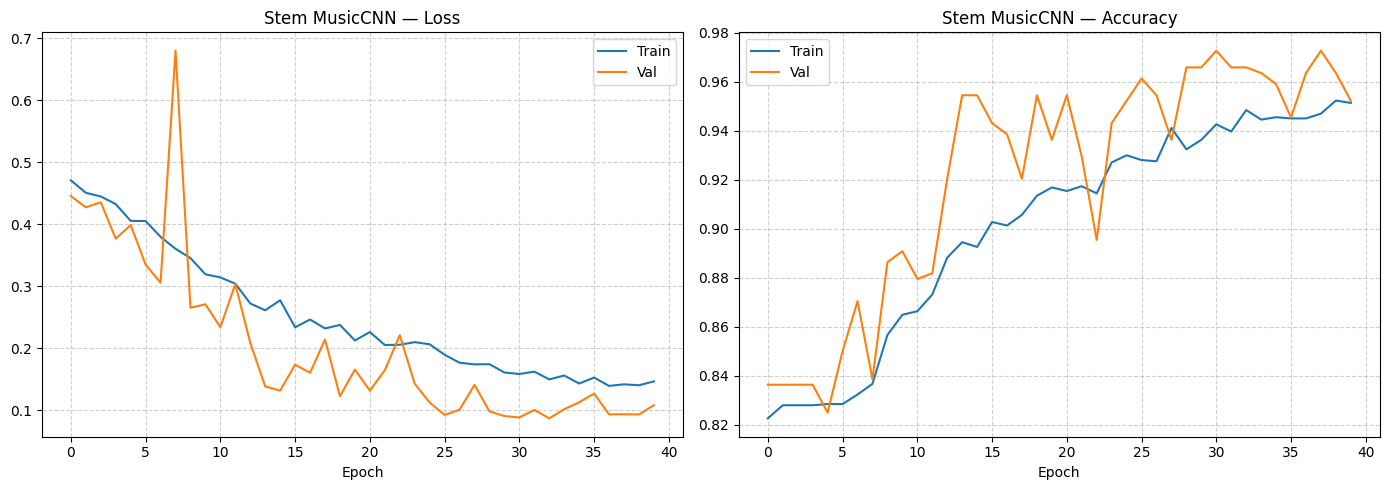

In [58]:
# Load best weights and history
model_stem_cnn.load_state_dict(torch.load(STEM_CNN_WEIGHTS_PATH, map_location=DEVICE))
model_stem_cnn.eval()

plot_history(stem_cnn_history, title="Stem MusicCNN")

---
#Part 9: Test on Generated Music From Different Sources

In [59]:
#Reload model definitions & weights
import torch, torch.nn as nn, numpy as np, librosa, glob, os, random
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED   = 42

In [60]:
#Load saved MusicCNN from Drive
BASE_DIR = "/content/drive/MyDrive/CS229"

model_cnn = MusicCNN(n_mels=64).to(DEVICE)
model_cnn.load_state_dict(torch.load(BASE_DIR + "/best_cnn.pt", map_location=DEVICE))
model_cnn.eval()
print("✓ MusicCNN loaded")

✓ MusicCNN loaded


In [61]:
#ElevenLabs AI clips
NEW_AI_DIR = "/content/drive/MyDrive/CS229/eleven_labs" # ← your folder

ai_files = (glob.glob(NEW_AI_DIR + "/**/*.mp3", recursive=True) +
            glob.glob(NEW_AI_DIR + "/**/*.wav", recursive=True) +
            glob.glob(NEW_AI_DIR + "/**/*.m4a", recursive=True))

# All ElevenLabs clips are label=1 (AI)
ext_files = [(f, 1) for f in ai_files]

random.seed(SEED)
random.shuffle(ext_files)

print(f"ElevenLabs clips found: {len(ai_files)}")

# Sanity check
import librosa
test_y, test_sr = librosa.load(ai_files[0], sr=22050, duration=5.0)
print(f"✓ Librosa can read files (sr={test_sr}, samples={len(test_y)})")

ElevenLabs clips found: 18
✓ Librosa can read files (sr=22050, samples=110250)


In [62]:
#Check what's actually in ElevenLabs folder
import librosa
from pathlib import Path

print("Files found:")
for path, _ in ext_files:
    size_mb = Path(path).stat().st_size / 1e6
    print(f"  {Path(path).name:<50} {size_mb:.2f} MB")

print(f"\nTotal: {len(ext_files)} files")

# Try loading the first file and print the exact error
print("\n── Attempting to load first file ──")
test_path = ext_files[0][0]
print(f"Path: {test_path}")
try:
    y, sr = librosa.load(test_path, sr=22050, duration=5.0)
    print(f"✓ Loaded fine — sr={sr}, samples={len(y)}")
except Exception as e:
    print(f"✗ Error: {type(e).__name__}: {e}")

# Check if ffmpeg is available (needed for mp3/m4a)
import subprocess
result = subprocess.run(["ffmpeg", "-version"], capture_output=True, text=True)
print(f"\nffmpeg available: {result.returncode == 0}")

# Check actual file format (regardless of extension)
import struct
with open(test_path, 'rb') as f:
    header = f.read(12)
print(f"\nFile header bytes: {header[:12]}")
print(f"File extension:    {Path(test_path).suffix}")

Files found:
  Finding_My_Own_Way_2026-03-12T075623 (1).mp3       0.74 MB
  Finding_My_Own_Way_2026-03-12T075623.mp3           0.74 MB
  Country_Night_2026-03-12T075143.mp3                0.74 MB
  Neon_Dreams_2026-03-12T075501 (1).mp3              0.74 MB
  Country_Night_2026-03-12T075143 (1).mp3            0.74 MB
  On_Another_Level_2026-03-12T075359 (1).mp3         4.34 MB
  Cybernetic_Beat_2026-03-12T075801.mp3              0.74 MB
  On_Another_Level_2026-03-12T075359.mp3             4.34 MB
  All_Ill_Ever_Need_2026-03-12T075540.mp3            0.74 MB
  Breaking_Through_the_Quiet_2026-03-12T075701 (1).mp3 0.74 MB
  Neon_Light_Chase_2026-03-12T074956 (1).mp3         4.34 MB
  All_Ill_Ever_Need_2026-03-12T075540 (1).mp3        0.74 MB
  Neon_Light_Chase_2026-03-12T075047.mp3             0.74 MB
  Breaking_Through_the_Quiet_2026-03-12T075701.mp3   0.74 MB
  Cybernetic_Beat_2026-03-12T075801 (1).mp3          0.74 MB
  Neon_Dreams_2026-03-12T075501.mp3                  0.74 MB
  Neon_Li

In [64]:
#Re-define audio_to_spectrogram, then run inference
import librosa, torch, numpy as np
from pathlib import Path
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

def audio_to_spectrogram(path, sr=22050, duration=30.0, n_mels=64,
                          n_fft=1024, hop_length=512):
    y, _ = librosa.load(path, sr=sr, duration=duration)
    target_rms  = 0.1
    current_rms = np.sqrt(np.mean(y**2)) + 1e-8
    y           = y * (target_rms / current_rms)
    n_samples   = int(sr * duration)
    if len(y) < n_samples:
        y = np.pad(y, (0, n_samples - len(y)))
    else:
        y = y[:n_samples]
    mel    = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels,
                                             n_fft=n_fft, hop_length=hop_length)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
    return torch.tensor(mel_db, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

# Quick sanity check before running all 18
test_path = ext_files[0][0]
spec = audio_to_spectrogram(test_path)
print(f"✓ audio_to_spectrogram works — shape: {spec.shape}")

# Now run inference
ext_cnn_probs, ext_cnn_paths = [], []
failed = []

model_cnn.eval()
with torch.no_grad():
    for i, (path, label) in enumerate(ext_files):
        try:
            spec = audio_to_spectrogram(path).to(DEVICE)
            prob = torch.sigmoid(model_cnn(spec)).item()
            ext_cnn_probs.append(prob)
            ext_cnn_paths.append(path)
        except Exception as e:
            failed.append((path, str(e)))

ext_cnn_probs = np.array(ext_cnn_probs)
detected      = (ext_cnn_probs > 0.5).sum()

print(f"\n=== MusicCNN — ElevenLabs Detection ===")
print(f"Clips tested:          {len(ext_cnn_probs)}")
print(f"Detected as AI:        {detected}  ({detected/len(ext_cnn_probs):.1%})")
print(f"Missed (called Human): {len(ext_cnn_probs)-detected}  ({(len(ext_cnn_probs)-detected)/len(ext_cnn_probs):.1%})")
print(f"Mean P(AI):            {ext_cnn_probs.mean():.4f}")
print(f"Failed:                {len(failed)}")

✓ audio_to_spectrogram works — shape: torch.Size([1, 1, 64, 1292])

=== MusicCNN — ElevenLabs Detection ===
Clips tested:          18
Detected as AI:        1  (5.6%)
Missed (called Human): 17  (94.4%)
Mean P(AI):            0.0782
Failed:                0


In [65]:
#See the confidence score for each clip individually
results_df = pd.DataFrame({
    'file':   [Path(p).name for p in ext_cnn_paths],
    'p_ai':   ext_cnn_probs.round(4),
    'called': ['AI ✓' if p > 0.5 else 'Human (missed)' for p in ext_cnn_probs],
}).sort_values('p_ai', ascending=False).reset_index(drop=True)

print(results_df.to_string(index=False))
print(f"\nMean P(AI): {ext_cnn_probs.mean():.4f}")
print(f"Max P(AI):  {ext_cnn_probs.max():.4f}")
print(f"Min P(AI):  {ext_cnn_probs.min():.4f}")

                                                file   p_ai         called
             Country_Night_2026-03-12T075143 (1).mp3 0.9645           AI ✓
           Cybernetic_Beat_2026-03-12T075801 (1).mp3 0.1312 Human (missed)
                 Country_Night_2026-03-12T075143.mp3 0.0947 Human (missed)
               Cybernetic_Beat_2026-03-12T075801.mp3 0.0676 Human (missed)
              Neon_Light_Chase_2026-03-12T075047.mp3 0.0611 Human (missed)
          Neon_Light_Chase_2026-03-12T074956 (1).mp3 0.0376 Human (missed)
         All_Ill_Ever_Need_2026-03-12T075540 (1).mp3 0.0209 Human (missed)
              Neon_Light_Chase_2026-03-12T074956.mp3 0.0138 Human (missed)
          Neon_Light_Chase_2026-03-12T075047 (1).mp3 0.0070 Human (missed)
            Finding_My_Own_Way_2026-03-12T075623.mp3 0.0038 Human (missed)
    Breaking_Through_the_Quiet_2026-03-12T075701.mp3 0.0014 Human (missed)
Breaking_Through_the_Quiet_2026-03-12T075701 (1).mp3 0.0010 Human (missed)
              On_Another_

Test on Stems

In [66]:
#Verify model_stem_cnn is in session
try:
    print(type(model_stem_cnn))
    print(f"Parameters: {sum(p.numel() for p in model_stem_cnn.parameters()):,}")
    print(f"Training mode: {model_stem_cnn.training}")  # should be False
except NameError:
    print("model_stem_cnn not in session — reloading from Drive...")
    model_stem_cnn = StemMusicCNN(n_mels=64).to(DEVICE)
    model_stem_cnn.load_state_dict(torch.load(BASE_DIR + "/best_stem_cnn.pt", map_location=DEVICE))
    model_stem_cnn.eval()
    print("✓ StemMusicCNN loaded")

<class '__main__.StemMusicCNN'>
Parameters: 407,073
Training mode: False


In [67]:
import subprocess, sys
from pathlib import Path

EXTERNAL_STEMS_DIR = "/content/external_elevenlabs_separated"
os.makedirs(EXTERNAL_STEMS_DIR, exist_ok=True)

def separate_clip(clip_path, out_dir):
    result = subprocess.run([
        sys.executable, "-m", "demucs",
        "--out",    out_dir,
        "--name",   "htdemucs",
        "--mp3",
        "--device", "cuda" if torch.cuda.is_available() else "cpu",
        clip_path
    ], capture_output=True, text=True)
    return result.returncode == 0

print(f"Separating {len(ext_files)} clips...")
sep_failed = []

for i, (path, _) in enumerate(ext_files):
    track_name   = Path(path).stem
    already_done = (Path(EXTERNAL_STEMS_DIR) / "htdemucs" / track_name).exists()
    if already_done:
        print(f"  [{i+1}/{len(ext_files)}] Already done — skipping")
        continue
    print(f"  [{i+1}/{len(ext_files)}] {Path(path).name}", end=" ... ")
    ok = separate_clip(path, EXTERNAL_STEMS_DIR)
    print("ok" if ok else "FAILED")
    if not ok:
        sep_failed.append(path)

print(f"\nDone. Failed: {len(sep_failed)}")

Separating 18 clips...
  [1/18] Finding_My_Own_Way_2026-03-12T075623 (1).mp3 ... ok
  [2/18] Finding_My_Own_Way_2026-03-12T075623.mp3 ... ok
  [3/18] Country_Night_2026-03-12T075143.mp3 ... ok
  [4/18] Neon_Dreams_2026-03-12T075501 (1).mp3 ... ok
  [5/18] Country_Night_2026-03-12T075143 (1).mp3 ... ok
  [6/18] On_Another_Level_2026-03-12T075359 (1).mp3 ... ok
  [7/18] Cybernetic_Beat_2026-03-12T075801.mp3 ... ok
  [8/18] On_Another_Level_2026-03-12T075359.mp3 ... ok
  [9/18] All_Ill_Ever_Need_2026-03-12T075540.mp3 ... ok
  [10/18] Breaking_Through_the_Quiet_2026-03-12T075701 (1).mp3 ... ok
  [11/18] Neon_Light_Chase_2026-03-12T074956 (1).mp3 ... ok
  [12/18] All_Ill_Ever_Need_2026-03-12T075540 (1).mp3 ... ok
  [13/18] Neon_Light_Chase_2026-03-12T075047.mp3 ... ok
  [14/18] Breaking_Through_the_Quiet_2026-03-12T075701.mp3 ... ok
  [15/18] Cybernetic_Beat_2026-03-12T075801 (1).mp3 ... ok
  [16/18] Neon_Dreams_2026-03-12T075501.mp3 ... ok
  [17/18] Neon_Light_Chase_2026-03-12T074956.mp3 .

In [68]:
#Re-define these in case of kernel restart
RELIABLE_STEMS  = ["vocals", "drums", "other"]
BLEED_THRESHOLD = 0.35
STEM_TYPES      = ["vocals", "drums", "other"]

def find_ext_stems(clip_path, out_dir=EXTERNAL_STEMS_DIR):
    track_name = Path(clip_path).stem
    stem_dir   = Path(out_dir) / "htdemucs" / track_name
    if not stem_dir.exists():
        return {}
    return {p.stem: str(p) for p in stem_dir.iterdir()
            if p.suffix in (".wav", ".mp3")}

def stem_onehot(stem_name, stem_types=STEM_TYPES):
    vec = torch.zeros(len(stem_types))
    if stem_name in stem_types:
        vec[stem_types.index(stem_name)] = 1.0
    return vec

def spectrogram_from_array(y, sr=22050, n_mels=64, n_fft=1024,
                            hop_length=512, duration=15.0):
    n_samples   = int(sr * duration)
    target_rms  = 0.1
    current_rms = np.sqrt(np.mean(y**2)) + 1e-8
    y = y * (target_rms / current_rms)
    if len(y) < n_samples:
        y = np.pad(y, (0, n_samples - len(y)))
    else:
        y = y[:n_samples]
    mel    = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels,
                                             n_fft=n_fft, hop_length=hop_length)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
    return torch.tensor(mel_db, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

#Sanity check, verify stems exist for first clip
test_stems = find_ext_stems(ext_files[0][0])
print(f"Stems found for first clip: {list(test_stems.keys())}")

Stems found for first clip: ['vocals', 'other', 'bass', 'drums']


In [71]:
ext_stem_rows = []

model_stem_cnn.eval()
with torch.no_grad():
    for i, (clip_path, label) in enumerate(ext_files):
        stems = find_ext_stems(clip_path)
        if not stems:
            print(f"  No stems found for {Path(clip_path).name} — skipping")
            continue

        for stem_name in RELIABLE_STEMS:
            if stem_name not in stems:
                continue
            try:

                y, sr = librosa.load(stems[stem_name], sr=22050, duration=15.0)
                spec  = spectrogram_from_array(y, sr).to(DEVICE)
                oh    = stem_onehot(stem_name).unsqueeze(0).to(DEVICE)
                prob  = torch.sigmoid(model_stem_cnn(spec, oh)).item()

                ext_stem_rows.append({
                    "file":      Path(clip_path).name,
                    "stem_name": stem_name,
                    "p_ai":      round(prob, 4),
                    "called":    "AI ✓" if prob > 0.5 else "Human (missed)",
                })
            except Exception as e:
                print(f"  Error [{stem_name}] {Path(clip_path).name}: {e}")

ext_stem_df = pd.DataFrame(ext_stem_rows)
print(f"\nScored {len(ext_stem_df)} stems across {ext_stem_df['file'].nunique()} tracks")


Scored 54 stems across 18 tracks


=== StemMusicCNN — ElevenLabs Detection ===

Total stems scored:    54
Detected as AI:        13  (24.1%)
Missed:                41  (75.9%)
Mean P(AI):            0.2611

Stem         Detected   Missed     Rate   Mean P(AI)
──────────────────────────────────────────────────
vocals              2       16    11.1%       0.1194
drums               5       13    27.8%       0.2720
other               6       12    33.3%       0.3920

Per-clip results:
                                                file stem_name   p_ai         called
         All_Ill_Ever_Need_2026-03-12T075540 (1).mp3     drums 0.0169 Human (missed)
         All_Ill_Ever_Need_2026-03-12T075540 (1).mp3     other 0.9815           AI ✓
         All_Ill_Ever_Need_2026-03-12T075540 (1).mp3    vocals 0.0105 Human (missed)
             All_Ill_Ever_Need_2026-03-12T075540.mp3     drums 0.0226 Human (missed)
             All_Ill_Ever_Need_2026-03-12T075540.mp3     other 0.8643           AI ✓
             All_Ill_Ever_Need_2026-

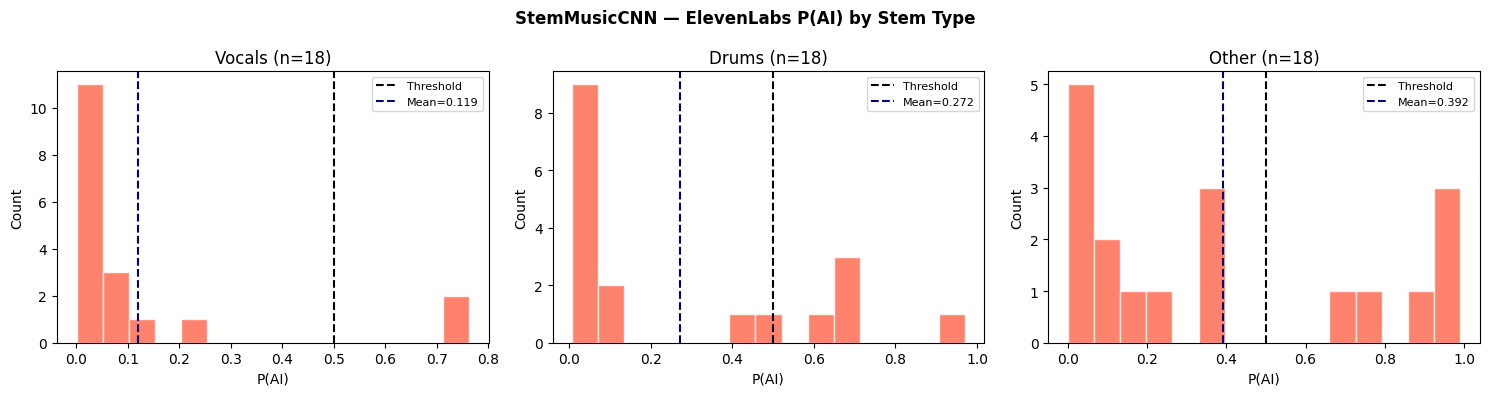

In [72]:
print("=== StemMusicCNN — ElevenLabs Detection ===\n")

total    = len(ext_stem_df)
detected = (ext_stem_df['p_ai'] > 0.5).sum()
print(f"Total stems scored:    {total}")
print(f"Detected as AI:        {detected}  ({detected/total:.1%})")
print(f"Missed:                {total-detected}  ({(total-detected)/total:.1%})")
print(f"Mean P(AI):            {ext_stem_df['p_ai'].mean():.4f}")

# Per stem type breakdown
print(f"\n{'Stem':<10} {'Detected':>10} {'Missed':>8} {'Rate':>8} {'Mean P(AI)':>12}")
print("─" * 50)
for stem_name in RELIABLE_STEMS:
    sub = ext_stem_df[ext_stem_df['stem_name'] == stem_name]
    if len(sub) == 0:
        continue
    det = (sub['p_ai'] > 0.5).sum()
    print(f"{stem_name:<10} {det:>10} {len(sub)-det:>8} "
          f"{det/len(sub):>8.1%} {sub['p_ai'].mean():>12.4f}")

# Per clip breakdown
print("\nPer-clip results:")
print(ext_stem_df.sort_values(['file','stem_name']).to_string(index=False))

# Confidence distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, stem_name in enumerate(RELIABLE_STEMS):
    sub = ext_stem_df[ext_stem_df['stem_name'] == stem_name]
    if len(sub) == 0:
        axes[i].set_title(f"{stem_name.capitalize()} (no data)")
        continue
    axes[i].hist(sub['p_ai'], bins=15, color='tomato', alpha=0.8, edgecolor='white')
    axes[i].axvline(0.5, linestyle='--', color='black', label='Threshold')
    axes[i].axvline(sub['p_ai'].mean(), linestyle='--', color='navy',
                    label=f"Mean={sub['p_ai'].mean():.3f}")
    axes[i].set_title(f"{stem_name.capitalize()} (n={len(sub)})")
    axes[i].set_xlabel("P(AI)"); axes[i].set_ylabel("Count")
    axes[i].legend(fontsize=8)
plt.suptitle("StemMusicCNN — ElevenLabs P(AI) by Stem Type", fontweight='bold')
plt.tight_layout()
plt.show()

Test on hand generated suno clips

In [73]:
#Load suno_test clips
import os, glob, random
from pathlib import Path

SUNO_TEST_DIR = "/content/drive/MyDrive/CS229/suno_test"

suno_test_files = (glob.glob(SUNO_TEST_DIR + "/**/*.mp3", recursive=True) +
                   glob.glob(SUNO_TEST_DIR + "/**/*.wav", recursive=True) +
                   glob.glob(SUNO_TEST_DIR + "/**/*.m4a", recursive=True))

suno_test_files = [(f, 1) for f in suno_test_files]  # all label=1 (AI)

print(f"Suno test clips found: {len(suno_test_files)}")
print("\nFiles:")
for f, _ in suno_test_files:
    size_mb = Path(f).stat().st_size / 1e6
    print(f"  {Path(f).name:<60} {size_mb:.2f} MB")

Suno test clips found: 11

Files:
  Thirty-Second Crush.mp3                                      1.26 MB
  Cheap Little Daydream.mp3                                    1.25 MB
  Half-Minute Hurricane.mp3                                    1.25 MB
  Half a Tank and Holding.mp3                                  1.54 MB
  Half a Minute Flex.mp3                                       0.85 MB
  Neon Memory Lane.mp3                                         1.22 MB
  Late Night Little Thing.mp3                                  1.38 MB
  Backyard Constellations.mp3                                  1.03 MB
  Burn It Into Me.mp3                                          1.81 MB
  Afterglow in My Eyes.mp3                                     1.54 MB
  Burnin' Down the Minute.mp3                                  2.56 MB


In [74]:
#Normalize + run MusicCNN
import torch, librosa, numpy as np

def audio_to_spectrogram_normalized(path, sr=22050, target_duration=30.0,
                                     n_mels=64, n_fft=1024, hop_length=512):
    """Load audio, pad or trim to exactly target_duration seconds, then spectrogram."""
    y, _ = librosa.load(path, sr=sr, duration=None)  # load full clip
    n_samples = int(sr * target_duration)

    # Pad if shorter than 30s, trim if longer
    if len(y) < n_samples:
        pad_amt = n_samples - len(y)
        y = np.pad(y, (0, pad_amt), mode='constant')
        print(f"  Padded  {Path(path).name} — original: {len(y)/sr:.1f}s → 30.0s")
    elif len(y) > n_samples:
        y = y[:n_samples]

    # Loudness normalization — same as training
    target_rms  = 0.1
    current_rms = np.sqrt(np.mean(y**2)) + 1e-8
    y           = y * (target_rms / current_rms)

    mel    = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels,
                                             n_fft=n_fft, hop_length=hop_length)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)

    return torch.tensor(mel_db, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # (1,1,M,T)


#Verify shapes are consistent
print("Verifying clip durations after normalization:")
for path, _ in suno_test_files[:3]:
    spec = audio_to_spectrogram_normalized(path)
    print(f"  {Path(path).name:<50} spec shape: {spec.shape}")

Verifying clip durations after normalization:
  Thirty-Second Crush.mp3                            spec shape: torch.Size([1, 1, 64, 1292])
  Cheap Little Daydream.mp3                          spec shape: torch.Size([1, 1, 64, 1292])
  Half-Minute Hurricane.mp3                          spec shape: torch.Size([1, 1, 64, 1292])



=== MusicCNN — Suno Test Clips ===
Clips tested:          11
Detected as AI:        4  (36.4%)
Missed (called Human): 7  (63.6%)
Mean P(AI):            0.3532
Failed:                0

Per-clip results:
                       file   p_ai         called
Backyard Constellations.mp3 0.9987           AI ✓
Late Night Little Thing.mp3 0.9034           AI ✓
  Half-Minute Hurricane.mp3 0.8430           AI ✓
       Neon Memory Lane.mp3 0.4786           AI ✓
   Afterglow in My Eyes.mp3 0.2257 Human (missed)
        Burn It Into Me.mp3 0.1612 Human (missed)
     Half a Minute Flex.mp3 0.0977 Human (missed)
  Cheap Little Daydream.mp3 0.0903 Human (missed)
Half a Tank and Holding.mp3 0.0777 Human (missed)
    Thirty-Second Crush.mp3 0.0086 Human (missed)
Burnin' Down the Minute.mp3 0.0006 Human (missed)


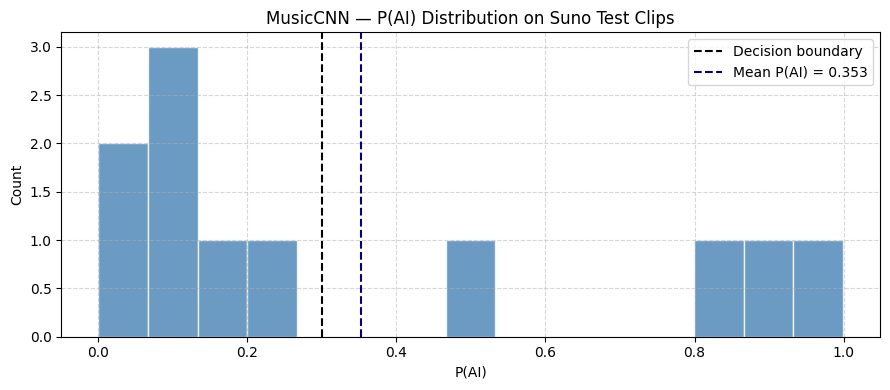

In [75]:
#MusicCNN inference
suno_cnn_probs, suno_cnn_paths = [], []
failed = []

model_cnn.eval()
with torch.no_grad():
    for i, (path, label) in enumerate(suno_test_files):
        try:
            spec = audio_to_spectrogram_normalized(path).to(DEVICE)
            prob = torch.sigmoid(model_cnn(spec)).item()
            suno_cnn_probs.append(prob)
            suno_cnn_paths.append(path)
        except Exception as e:
            print(f"  Failed: {Path(path).name} — {e}")
            failed.append((path, str(e)))

suno_cnn_probs = np.array(suno_cnn_probs)
detected       = (suno_cnn_probs > 0.3).sum()

print(f"\n=== MusicCNN — Suno Test Clips ===")
print(f"Clips tested:          {len(suno_cnn_probs)}")
print(f"Detected as AI:        {detected}  ({detected/len(suno_cnn_probs):.1%})")
print(f"Missed (called Human): {len(suno_cnn_probs)-detected}  ({(len(suno_cnn_probs)-detected)/len(suno_cnn_probs):.1%})")
print(f"Mean P(AI):            {suno_cnn_probs.mean():.4f}")
print(f"Failed:                {len(failed)}")

# Per clip breakdown
import pandas as pd
suno_cnn_df = pd.DataFrame({
    'file':   [Path(p).name for p in suno_cnn_paths],
    'p_ai':   suno_cnn_probs.round(4),
    'called': ['AI ✓' if p > 0.3 else 'Human (missed)' for p in suno_cnn_probs],
}).sort_values('p_ai', ascending=False).reset_index(drop=True)

print("\nPer-clip results:")
print(suno_cnn_df.to_string(index=False))

# Confidence distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 4))
plt.hist(suno_cnn_probs, bins=15, color='steelblue', alpha=0.8, edgecolor='white')
plt.axvline(0.3, linestyle='--', color='black', label='Decision boundary')
plt.axvline(suno_cnn_probs.mean(), linestyle='--', color='navy',
            label=f'Mean P(AI) = {suno_cnn_probs.mean():.3f}')
plt.xlabel("P(AI)"); plt.ylabel("Count")
plt.title("MusicCNN — P(AI) Distribution on Suno Test Clips")
plt.legend(); plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

In [76]:
# Separate stems with Demucs
import subprocess, sys

SUNO_TEST_STEMS_DIR = "/content/suno_test_separated"
os.makedirs(SUNO_TEST_STEMS_DIR, exist_ok=True)

print(f"Separating {len(suno_test_files)} clips...")
sep_failed = []

for i, (path, _) in enumerate(suno_test_files):
    track_name   = Path(path).stem
    already_done = (Path(SUNO_TEST_STEMS_DIR) / "htdemucs" / track_name).exists()
    if already_done:
        print(f"  [{i+1}/{len(suno_test_files)}] Already done — skipping")
        continue
    print(f"  [{i+1}/{len(suno_test_files)}] {Path(path).name}", end=" ... ")
    result = subprocess.run([
        sys.executable, "-m", "demucs",
        "--out",    SUNO_TEST_STEMS_DIR,
        "--name",   "htdemucs",
        "--mp3",
        "--device", "cuda" if torch.cuda.is_available() else "cpu",
        path
    ], capture_output=True, text=True)
    print("ok" if result.returncode == 0 else "FAILED")
    if result.returncode != 0:
        sep_failed.append(path)

print(f"\nDone. Failed: {len(sep_failed)}")

Separating 11 clips...
  [1/11] Thirty-Second Crush.mp3 ... ok
  [2/11] Cheap Little Daydream.mp3 ... ok
  [3/11] Half-Minute Hurricane.mp3 ... ok
  [4/11] Half a Tank and Holding.mp3 ... ok
  [5/11] Half a Minute Flex.mp3 ... ok
  [6/11] Neon Memory Lane.mp3 ... ok
  [7/11] Late Night Little Thing.mp3 ... ok
  [8/11] Backyard Constellations.mp3 ... ok
  [9/11] Burn It Into Me.mp3 ... ok
  [10/11] Afterglow in My Eyes.mp3 ... ok
  [11/11] Burnin' Down the Minute.mp3 ... ok

Done. Failed: 0


In [77]:
# StemMusicCNN inference
RELIABLE_STEMS  = ["vocals", "drums", "other"]
BLEED_THRESHOLD = 0.35
STEM_TYPES      = ["vocals", "drums", "other"]

def find_suno_test_stems(clip_path):
    track_name = Path(clip_path).stem
    stem_dir   = Path(SUNO_TEST_STEMS_DIR) / "htdemucs" / track_name
    if not stem_dir.exists():
        return {}
    return {p.stem: str(p) for p in stem_dir.iterdir()
            if p.suffix in (".wav", ".mp3")}

def spectrogram_from_array_normalized(y, sr=22050, target_duration=15.0,
                                       n_mels=64, n_fft=1024, hop_length=512):
    """Same normalization as training — pad/trim to target_duration."""
    n_samples   = int(sr * target_duration)
    target_rms  = 0.1
    current_rms = np.sqrt(np.mean(y**2)) + 1e-8
    y = y * (target_rms / current_rms)
    if len(y) < n_samples:
        y = np.pad(y, (0, n_samples - len(y)), mode='constant')
    else:
        y = y[:n_samples]
    mel    = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels,
                                             n_fft=n_fft, hop_length=hop_length)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
    return torch.tensor(mel_db, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

def stem_onehot(stem_name):
    vec = torch.zeros(len(STEM_TYPES))
    if stem_name in STEM_TYPES:
        vec[STEM_TYPES.index(stem_name)] = 1.0
    return vec

suno_stem_rows = []

model_stem_cnn.eval()
with torch.no_grad():
    for i, (clip_path, label) in enumerate(suno_test_files):
        stems = find_suno_test_stems(clip_path)
        if not stems:
            print(f"  No stems found for {Path(clip_path).name} — skipping")
            continue

        for stem_name in RELIABLE_STEMS:
            if stem_name not in stems:
                continue
            try:
                bleed = bleed_ratio(stems[stem_name], stem_name)
                if bleed > BLEED_THRESHOLD:
                    continue

                y, sr = librosa.load(stems[stem_name], sr=22050, duration=None)
                spec  = spectrogram_from_array_normalized(y, sr).to(DEVICE)
                oh    = stem_onehot(stem_name).unsqueeze(0).to(DEVICE)
                prob  = torch.sigmoid(model_stem_cnn(spec, oh)).item()

                suno_stem_rows.append({
                    "file":      Path(clip_path).name,
                    "stem_name": stem_name,
                    "p_ai":      round(prob, 4),
                    "bleed":     round(bleed, 4),
                    "called":    "AI ✓" if prob > 0.5 else "Human (missed)",
                })
            except Exception as e:
                print(f"  Error [{stem_name}] {Path(clip_path).name}: {e}")

suno_stem_df = pd.DataFrame(suno_stem_rows)
print(f"Scored {len(suno_stem_df)} stems across {suno_stem_df['file'].nunique()} tracks")

Scored 25 stems across 11 tracks


=== StemMusicCNN — Suno Test Clips ===

Total stems scored:    25
Detected as AI:        6  (24.0%)
Missed:                19  (76.0%)
Mean P(AI):            0.3151

Stem         Detected   Missed     Rate   Mean P(AI)
──────────────────────────────────────────────────
vocals              0        4     0.0%       0.1016
drums               3        8    27.3%       0.3520
other               3        7    30.0%       0.3599

Per-clip results:
                       file stem_name   p_ai  bleed         called
   Afterglow in My Eyes.mp3     drums 0.2442 0.2895 Human (missed)
   Afterglow in My Eyes.mp3     other 0.0093 0.0842 Human (missed)
Backyard Constellations.mp3     drums 0.4849 0.2146 Human (missed)
        Burn It Into Me.mp3     drums 0.9712 0.1876           AI ✓
        Burn It Into Me.mp3     other 0.1488 0.0876 Human (missed)
Burnin' Down the Minute.mp3     drums 0.0125 0.0818 Human (missed)
Burnin' Down the Minute.mp3     other 0.0455 0.0848 Human (missed)
Burnin' Down the

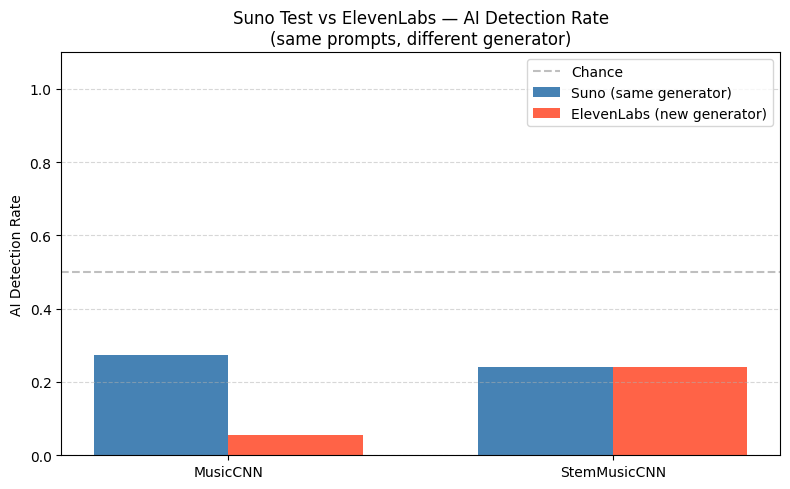

In [78]:
#StemCNN results + comparison against ElevenLabs
total    = len(suno_stem_df)
detected = (suno_stem_df['p_ai'] > 0.5).sum()

print("=== StemMusicCNN — Suno Test Clips ===\n")
print(f"Total stems scored:    {total}")
print(f"Detected as AI:        {detected}  ({detected/total:.1%})")
print(f"Missed:                {total-detected}  ({(total-detected)/total:.1%})")
print(f"Mean P(AI):            {suno_stem_df['p_ai'].mean():.4f}")

print(f"\n{'Stem':<10} {'Detected':>10} {'Missed':>8} {'Rate':>8} {'Mean P(AI)':>12}")
print("─" * 50)
for stem_name in RELIABLE_STEMS:
    sub = suno_stem_df[suno_stem_df['stem_name'] == stem_name]
    if len(sub) == 0:
        continue
    det = (sub['p_ai'] > 0.5).sum()
    print(f"{stem_name:<10} {det:>10} {len(sub)-det:>8} "
          f"{det/len(sub):>8.1%} {sub['p_ai'].mean():>12.4f}")

print("\nPer-clip results:")
print(suno_stem_df.sort_values(['file','stem_name']).to_string(index=False))

#Side by side: Suno test vs ElevenLabs
print("\n\n=== Head-to-head: Suno test vs ElevenLabs ===\n")

# Pull ElevenLabs scores from earlier cells
el_cnn_det  = (ext_cnn_probs > 0.5).mean()   if 'ext_cnn_probs'  in dir() else float('nan')
el_stem_det = (ext_stem_df['p_ai'] > 0.5).mean() if 'ext_stem_df' in dir() else float('nan')

summary = pd.DataFrame({
    "Model":           ["MusicCNN",                          "StemMusicCNN"],
    "Suno detection":  [(suno_cnn_probs > 0.5).mean(),       detected/total],
    "EL detection":    [el_cnn_det,                          el_stem_det],
    "Suno mean P(AI)": [suno_cnn_probs.mean(),               suno_stem_df['p_ai'].mean()],
    "EL mean P(AI)":   [ext_cnn_probs.mean() if 'ext_cnn_probs' in dir() else float('nan'),
                        ext_stem_df['p_ai'].mean() if 'ext_stem_df' in dir() else float('nan')],
}).round(4)

print(summary.to_string(index=False))

# Bar chart
x     = np.arange(2)
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, summary["Suno detection"],  width, label='Suno (same generator)', color='steelblue')
ax.bar(x + width/2, summary["EL detection"],    width, label='ElevenLabs (new generator)', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(['MusicCNN', 'StemMusicCNN'])
ax.set_ylim(0, 1.1)
ax.set_ylabel("AI Detection Rate")
ax.set_title("Suno Test vs ElevenLabs — AI Detection Rate\n(same prompts, different generator)")
ax.axhline(0.5, linestyle='--', color='gray', alpha=0.5, label='Chance')
ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

In [81]:
import os
os.popen('find / -name "*.ipynb" 2>/dev/null').read()

'/opt/nvidia/nsight-compute/2025.1.1/host/target-linux-x64/python/packages/nsys_recipe/recipes/cuda_api_sum/stats.ipynb\n/opt/nvidia/nsight-compute/2025.1.1/host/target-linux-x64/python/packages/nsys_recipe/recipes/network_sum/stats.ipynb\n/opt/nvidia/nsight-compute/2025.1.1/host/target-linux-x64/python/packages/nsys_recipe/recipes/cuda_api_sync/analysis.ipynb\n/opt/nvidia/nsight-compute/2025.1.1/host/target-linux-x64/python/packages/nsys_recipe/recipes/cuda_gpu_kern_pace/pace.ipynb\n/opt/nvidia/nsight-compute/2025.1.1/host/target-linux-x64/python/packages/nsys_recipe/recipes/network_map_aws/heatmap.ipynb\n/opt/nvidia/nsight-compute/2025.1.1/host/target-linux-x64/python/packages/nsys_recipe/recipes/nccl_sum/stats.ipynb\n/opt/nvidia/nsight-compute/2025.1.1/host/target-linux-x64/python/packages/nsys_recipe/recipes/nccl_gpu_proj_sum/stats.ipynb\n/opt/nvidia/nsight-compute/2025.1.1/host/target-linux-x64/python/packages/nsys_recipe/recipes/nvtx_gpu_proj_trace/trace.ipynb\n/opt/nvidia/nsight

In [80]:
from google.colab import files
files.download('CS229_AI_Music_Detection.ipynb')

FileNotFoundError: Cannot find file: CS229_AI_Music_Detection.ipynb